# Análisis del dataset final

## Import librerías y dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "C:\Users\Usuario\anaconda3\Lib\si

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "C:\Users\Usuario\anaconda3\Lib\si

AttributeError: _ARRAY_API not found

Columna 'SEQN' eliminada.
Dataset cargado con éxito: 2687 filas y 124 columnas.


In [6]:
# Carga del dataset 
try:
    df = pd.read_csv('data/merged_all_clean.csv')
    
    if 'SEQN' in df.columns:
        df.drop(columns=['SEQN'], inplace=True)
        print("Columna 'SEQN' eliminada.")
        print(f"Dataset cargado con éxito: {df.shape[0]} filas y {df.shape[1]} columnas.")
    else:
        print("No se encontró columna 'SEQN'.")
        print(f"Dataset cargado con éxito: {df.shape[0]} filas y {df.shape[1]} columnas.")
        
except FileNotFoundError:
    print("Error: No se encontró el archivo 'all_merged_clean.csv' en la carpeta 'data/'.")

Columna 'SEQN' eliminada.
Dataset cargado con éxito: 2687 filas y 124 columnas.


## Análisis Variables

In [7]:
# Identificación inicial
print("--- Tipos de datos ---")
print(df.dtypes.value_counts())

# Categorización basada en el Diccionario NHANES 
cols_categoricas = [
    'RIDSTATR', 'RIAGENDR', 'RIDRETH1', 'RIDRETH3', 
    'DMDBORN4', 'DMDEDUC2', 'DMDMARTZ', 'DMDHHSIZ',
    'LBDBPBLC', 'LBDBCDLC'
]

cols_numericas = df.select_dtypes(include=[np.number]).columns.difference(cols_categoricas).tolist()

# Convertimos explícitamente las categóricas al tipo 'category' de pandas
for col in cols_categoricas:
    if col in df.columns:
        df[col] = df[col].astype('category')

print(f"--- Clasificación ---")
print(f"Variables Categóricas: {len(cols_categoricas)}")
print(f"Variables Numéricas: {len(cols_numericas)}")

# Verificación rápida del estado actual
df.head()

--- Tipos de datos ---
float64    122
str          2
Name: count, dtype: int64
--- Clasificación ---
Variables Categóricas: 10
Variables Numéricas: 114


,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,DMDHHSIZ,WTINT2YR,...,LBDBCDLC,LBXTHG,LBDTHGSI,LBDTHGLC,LBXBSE,LBDBSESI,LBDBSELC,LBXBMN,LBDBMNSI,LBDBMNLC
0,12.0,2.0,1.0,43.0,5.0,6.0,2.0,2.0,4.0,50055.450807,...,5.397605e-79,1.01,5.04,5.397605e-79,189.2,2.40,5.397605e-79,10.94,199.13,5.397605e-79
1,12.0,2.0,1.0,66.0,3.0,3.0,2.0,1.0,2.0,29087.450605,...,5.397605e-79,9.64,48.10,5.397605e-79,192.3,2.44,5.397605e-79,7.74,140.88,5.397605e-79
2,12.0,2.0,2.0,44.0,2.0,2.0,1.0,2.0,7.0,80062.674301,...,5.397605e-79,0.55,2.74,5.397605e-79,160.5,2.04,5.397605e-79,11.93,217.15,5.397605e-79
3,12.0,2.0,1.0,34.0,1.0,1.0,1.0,1.0,3.0,30995.282610,...,5.397605e-79,0.34,1.70,5.397605e-79,183.3,2.33,5.397605e-79,10.94,199.13,5.397605e-79
4,12.0,2.0,1.0,51.0,3.0,3.0,1.0,1.0,4.0,41925.463225,...,5.397605e-79,0.27,1.35,5.397605e-79,185.0,2.35,5.397605e-79,9.36,170.37,5.397605e-79


## Valores nulos

In [13]:
# Cálculo de porcentajes de nulos
null_counts = df.isnull().sum()
null_percentages = (null_counts / len(df)) * 100

# Tabla resumen de nulos
df_nulls = pd.DataFrame({
    'Variable': null_percentages.index,
    'Porcentaje_Nulos': null_percentages.values
}).sort_values(by='Porcentaje_Nulos', ascending=False)

# Clasificación por rangos 
bins = [0, 10, 20, 30, 100]
labels = ['0-10%', '10-20%', '20-30%', '>30%']

# Creamos una columna de rango 
df_nulls['Rango'] = pd.cut(df_nulls['Porcentaje_Nulos'], bins=bins, labels=labels, include_lowest=True)

# Mostrar conteo de variables por rango
resumen_rangos = df_nulls['Rango'].value_counts().sort_index()

print("--- Resumen de Variables por Rango de Nulos ---")
for rango, cantidad in resumen_rangos.items():
    print(f"Rango {rango}: {cantidad} variables")

# Mostrar las variables con más nulos 
print("\nPorcentage de nulos por variable")
print(df_nulls.to_string(index=False))

--- Resumen de Variables por Rango de Nulos ---
Rango 0-10%: 97 variables
Rango 10-20%: 21 variables
Rango 20-30%: 6 variables
Rango >30%: 0 variables

Porcentage de nulos por variable
Variable  Porcentaje_Nulos  Rango
  BAQ170         26.572386 20-30%
  BAQ160         24.451061 20-30%
DSDANCNT         22.143655 20-30%
DSD010AN         22.143655 20-30%
  DSD010         21.957574 20-30%
DSDCOUNT         21.957574 20-30%
 BAXTC41         19.278005 10-20%
 BAXPF41         19.129140 10-20%
 BAXTC31         18.756978 10-20%
 BAXPF31         18.570897 10-20%
 BAXTC21         17.752140 10-20%
 BAXPF21         17.714924 10-20%
 BAXTC11         17.603275 10-20%
 BAXPF11         17.566059 10-20%
  BAQ173         17.231113 10-20%
  BAQ150         17.119464 10-20%
  BAQ132         16.226275 10-20%
  BAQ140         16.226275 10-20%
INDFMPIR         12.914031 10-20%
LBDLDLSI         11.127652 10-20%
  LBDLDL         11.127652 10-20%
LBDLDMSI         11.127652 10-20%
 LBDLDLM         11.127652 10-20%

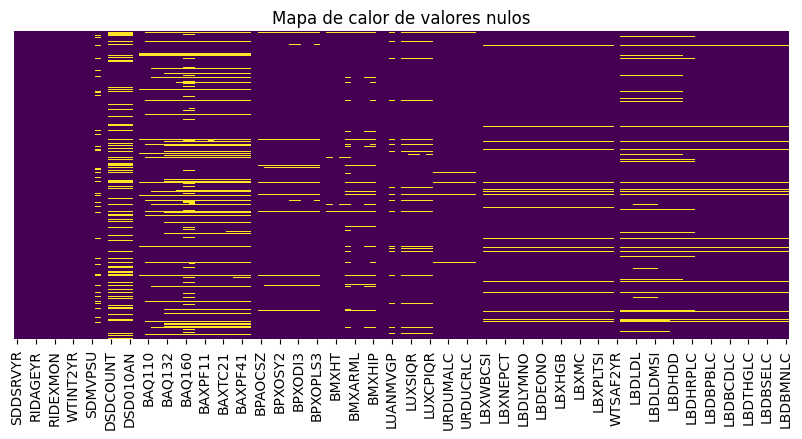

In [14]:
# Visualización rápida de nulos
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.show()

## Distribuciones y Outliers

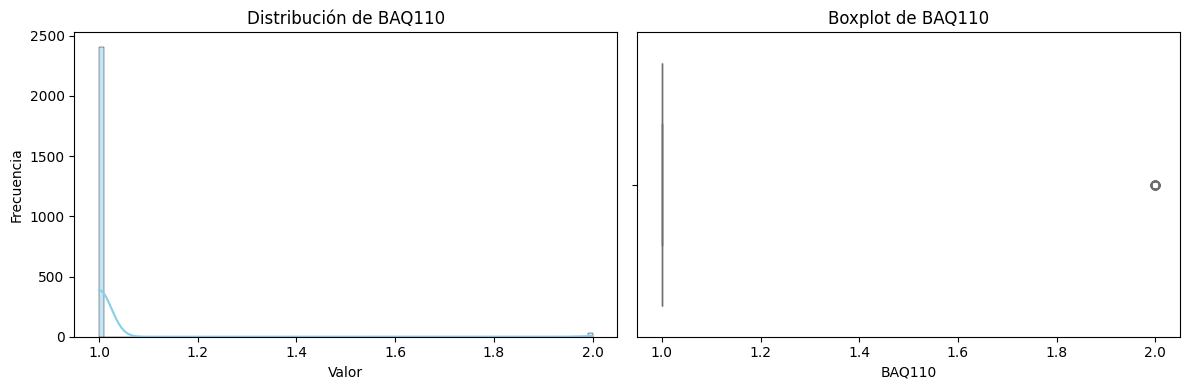

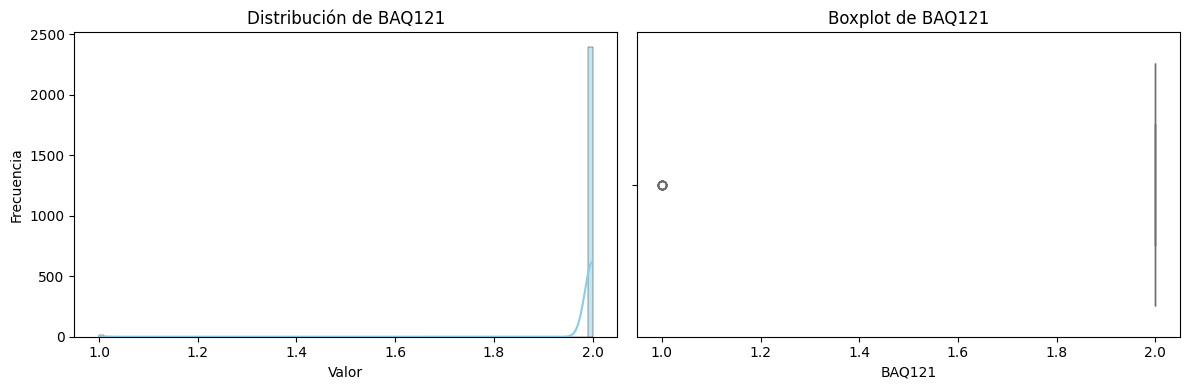

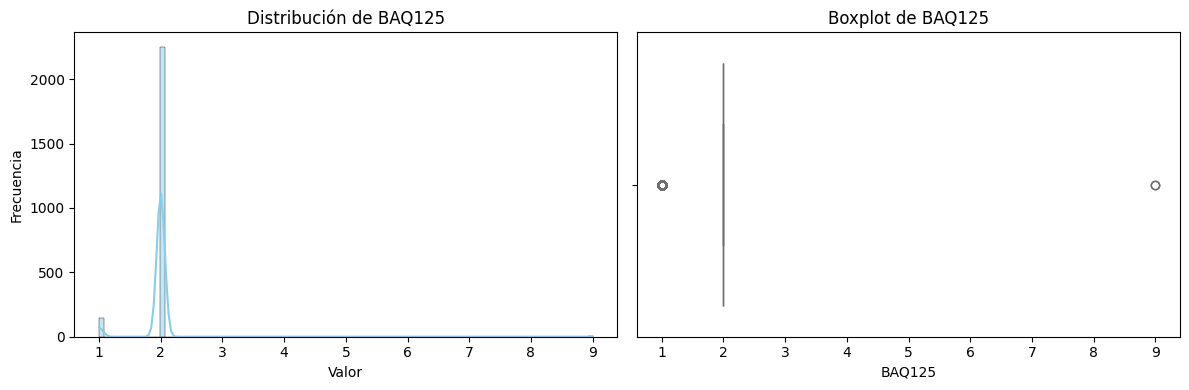

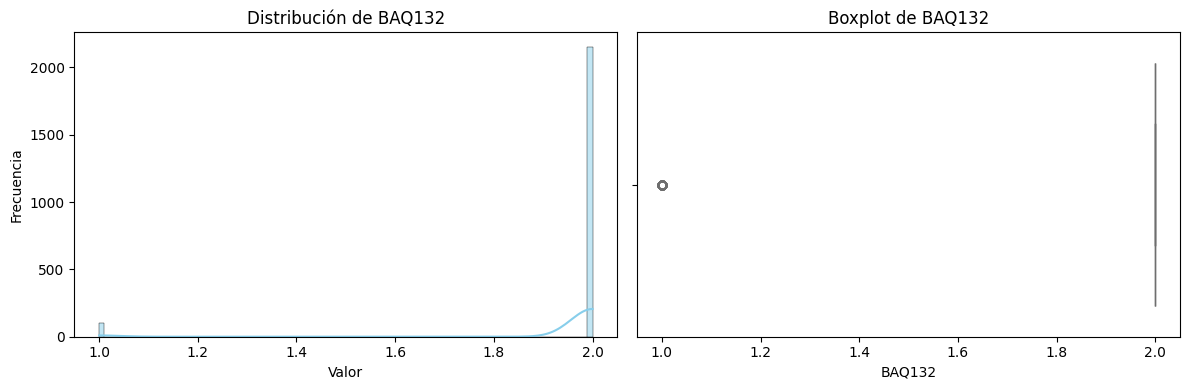

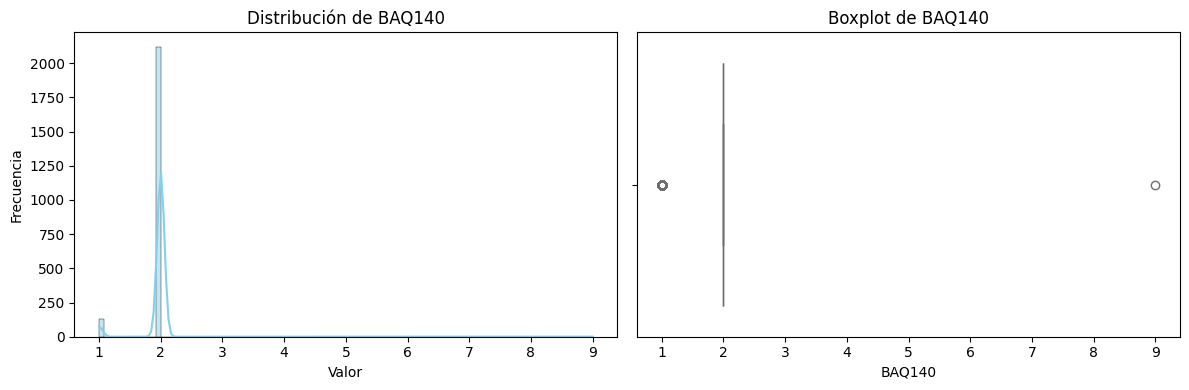

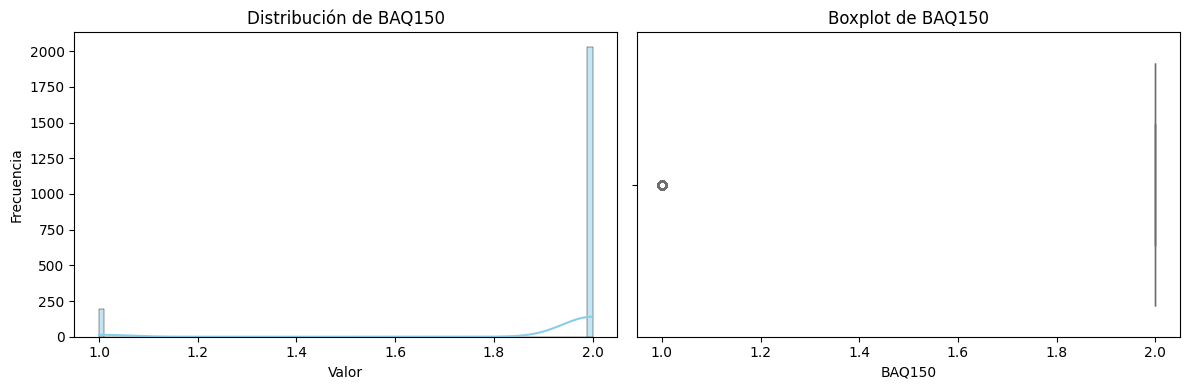

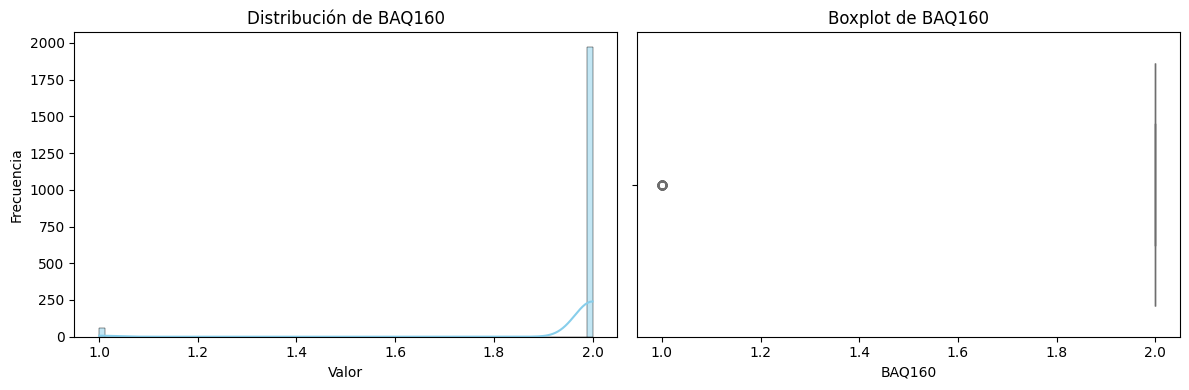

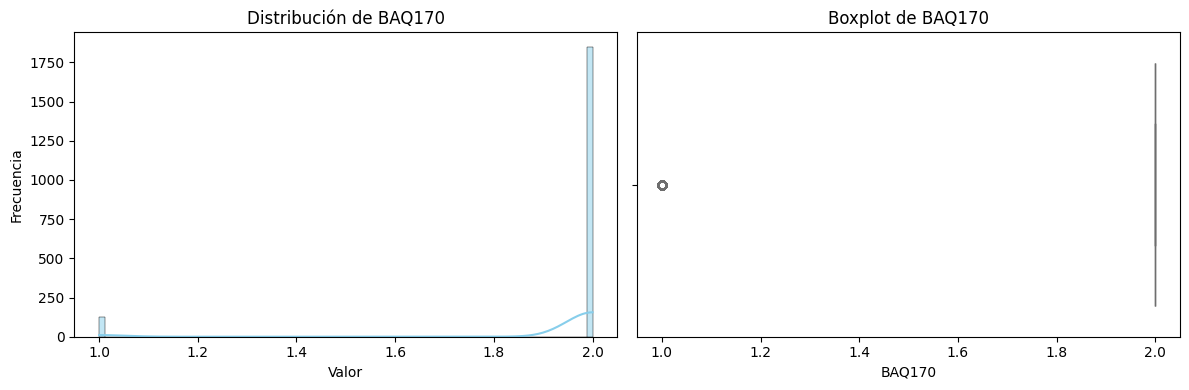

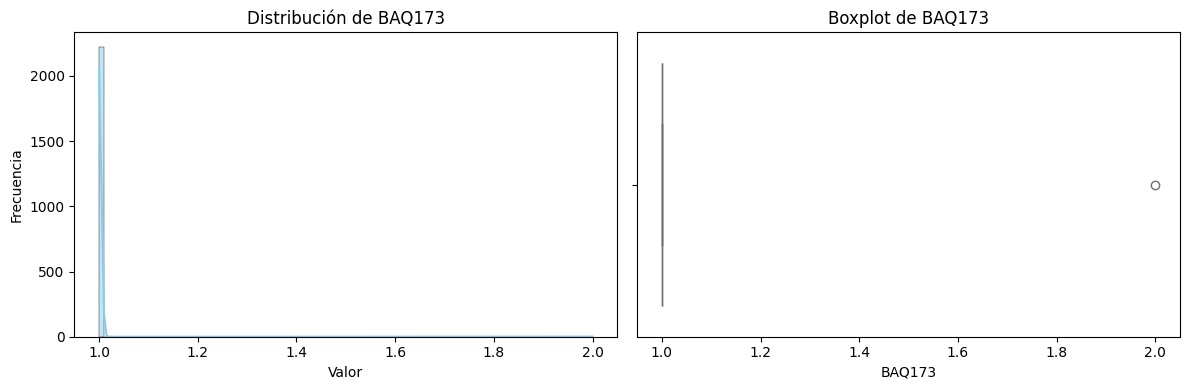

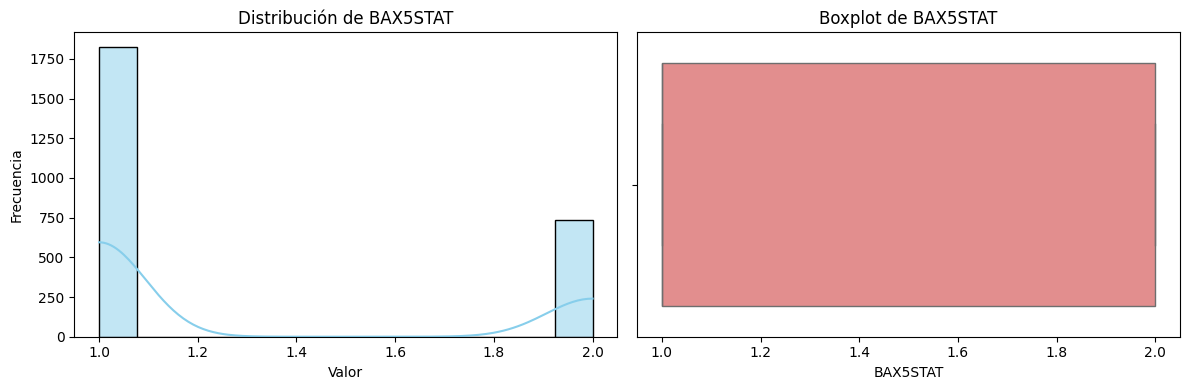

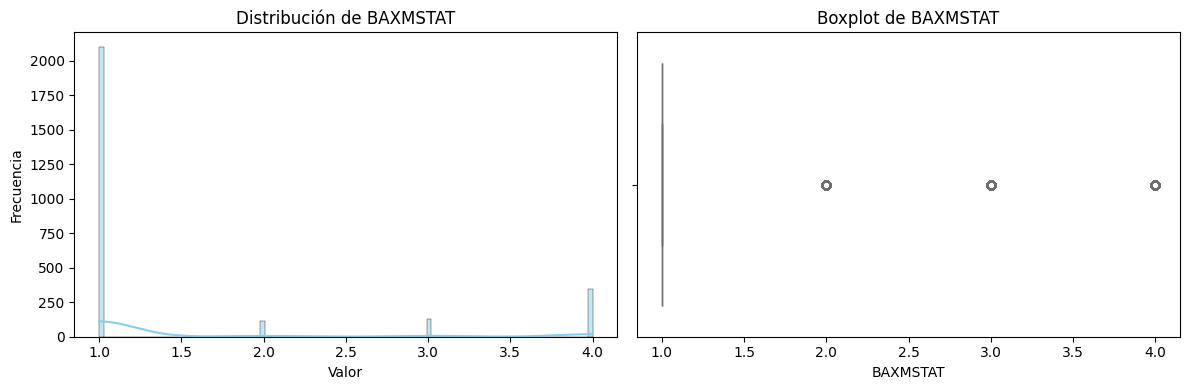

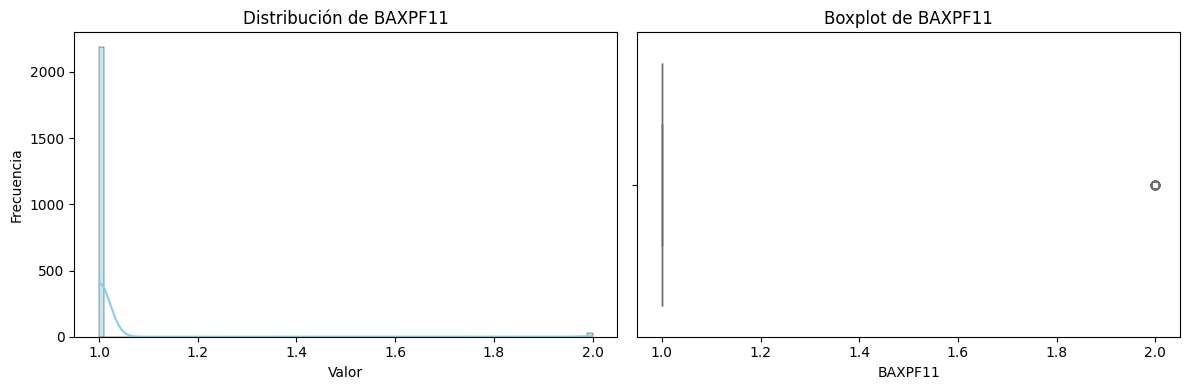

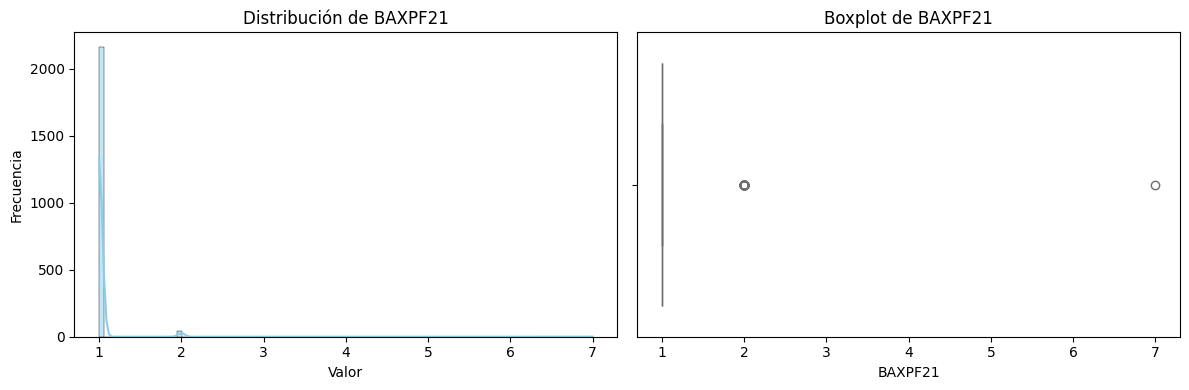

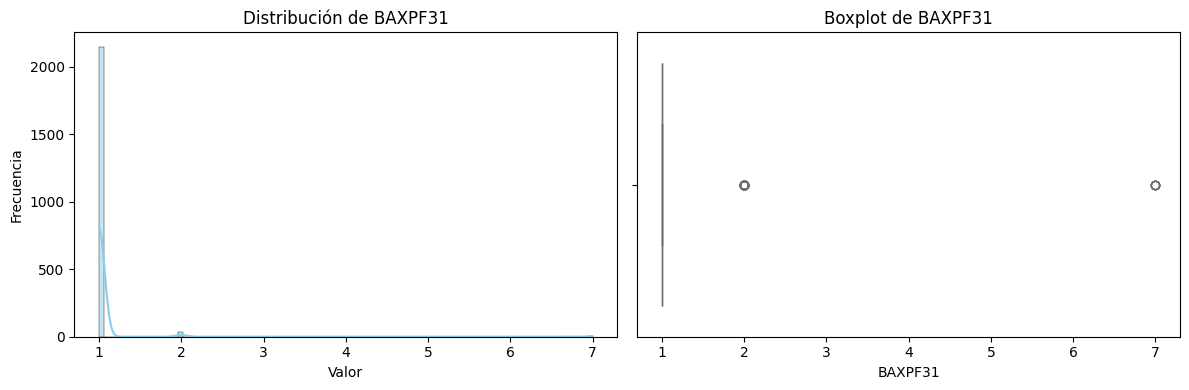

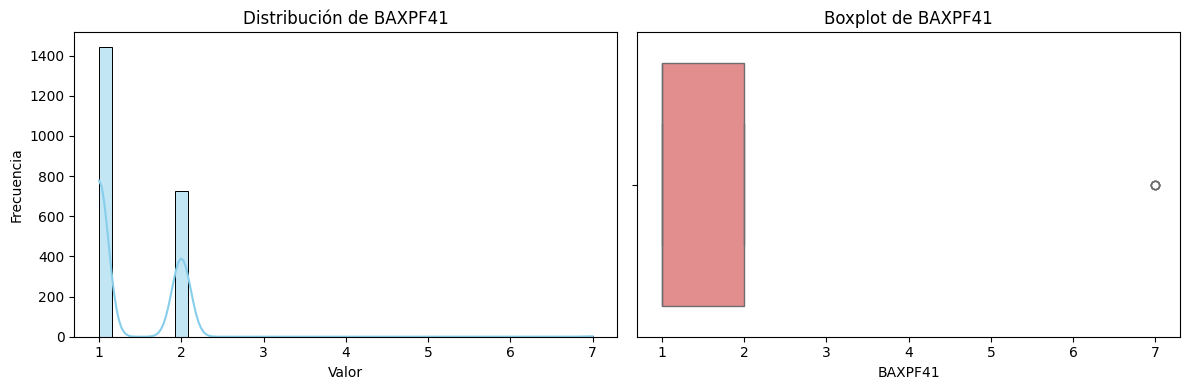

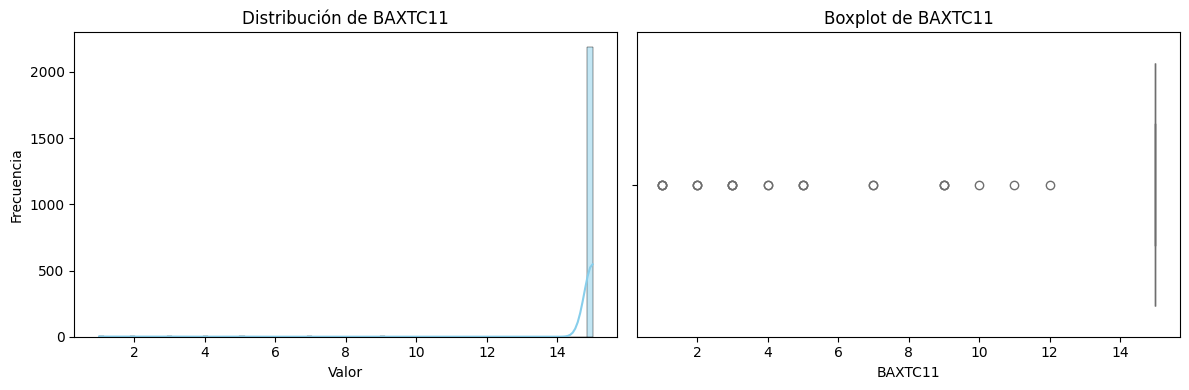

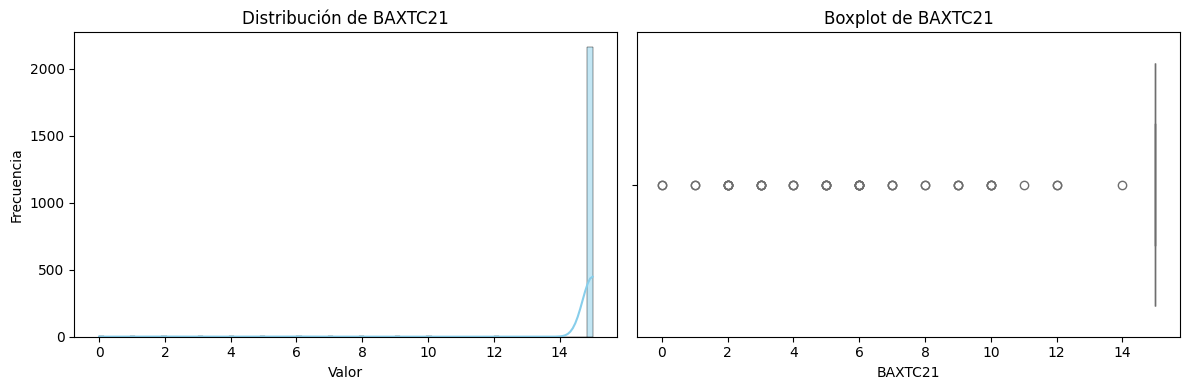

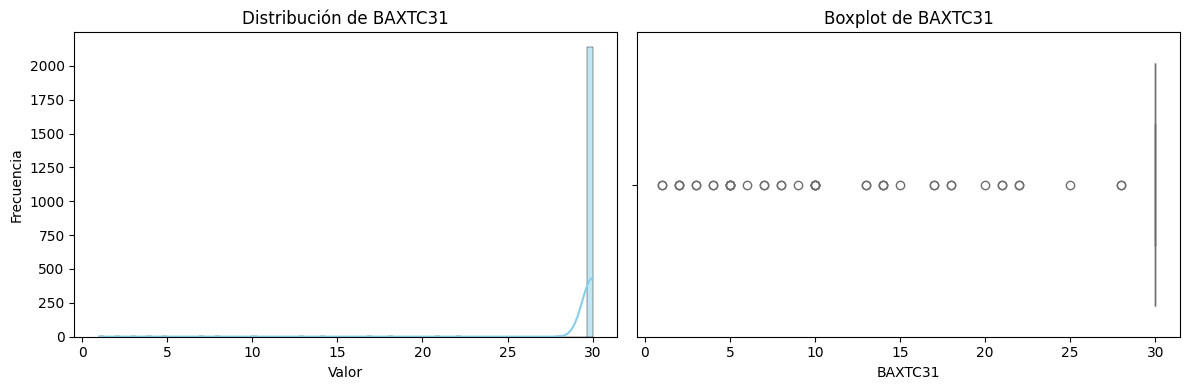

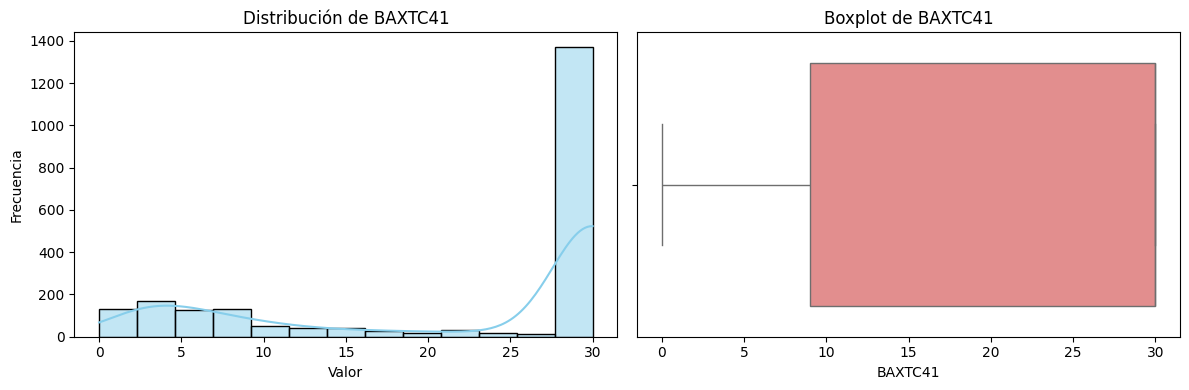

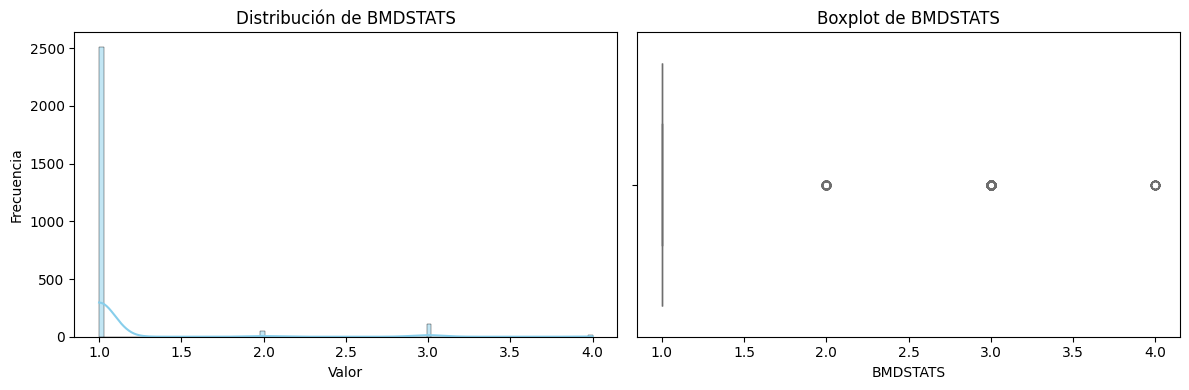

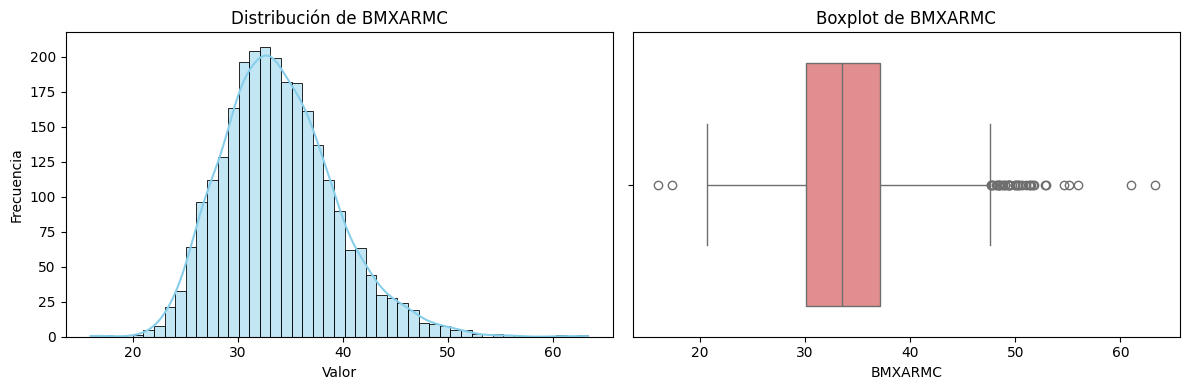

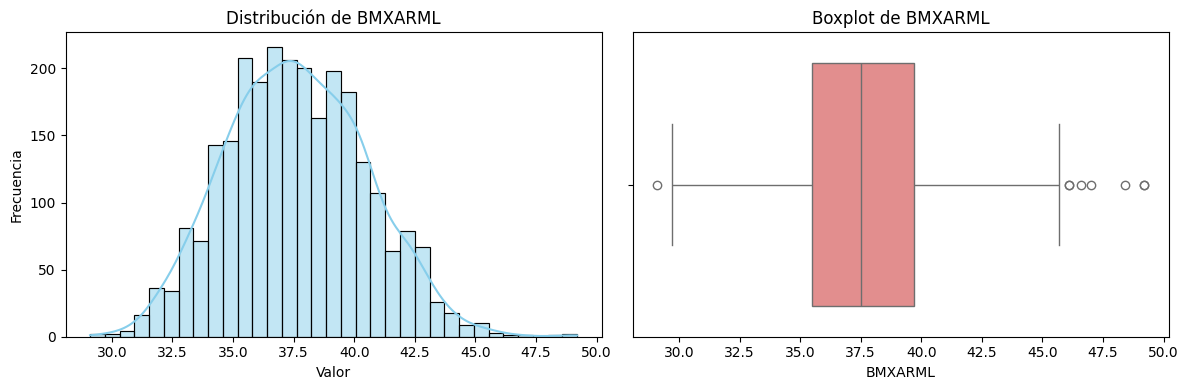

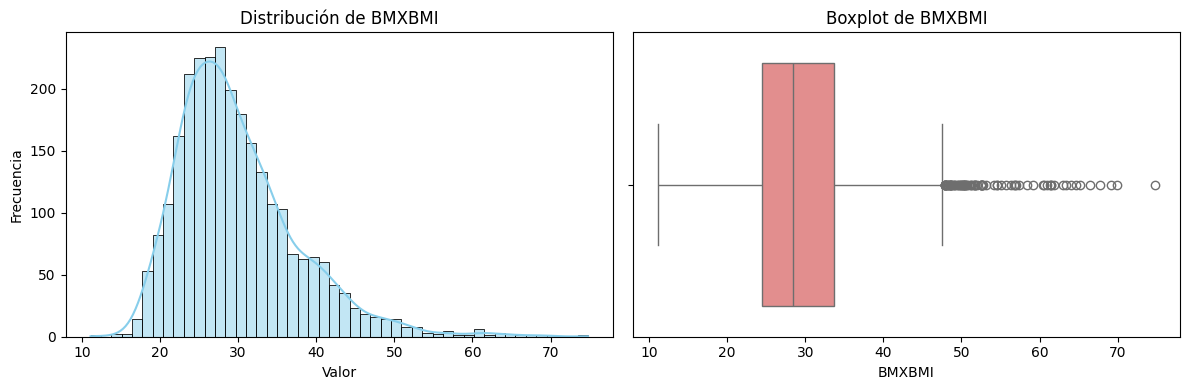

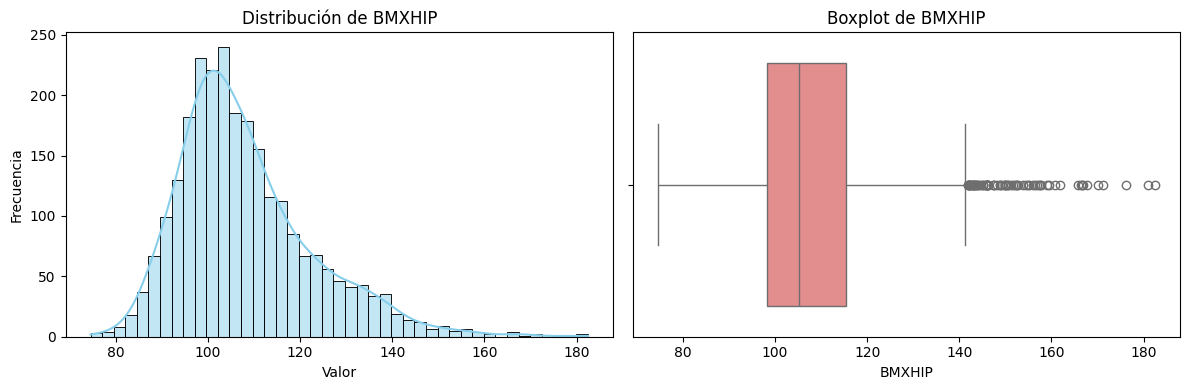

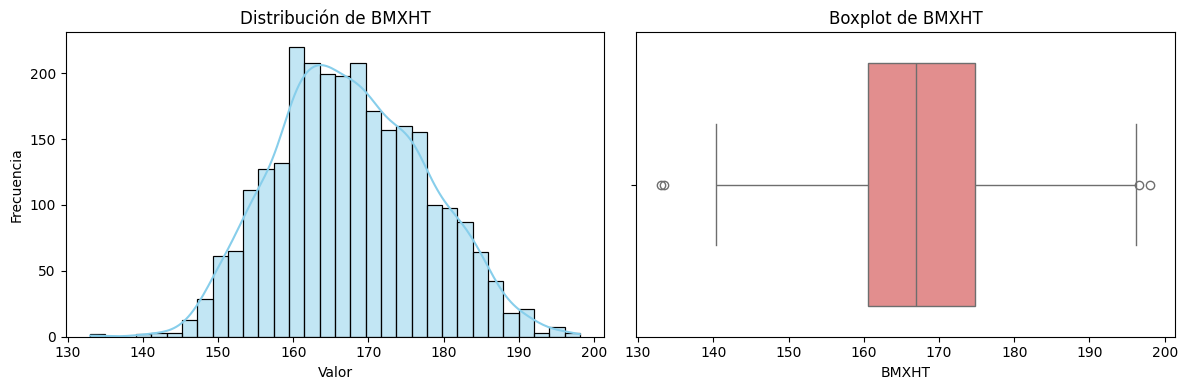

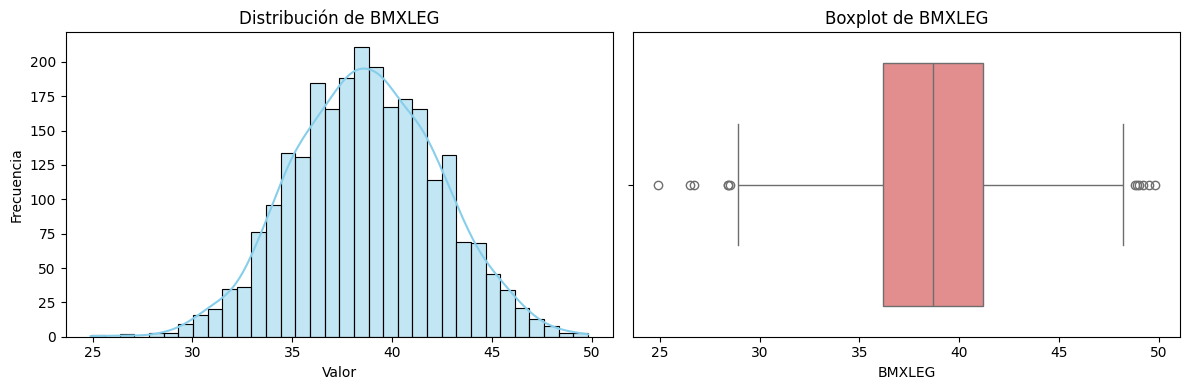

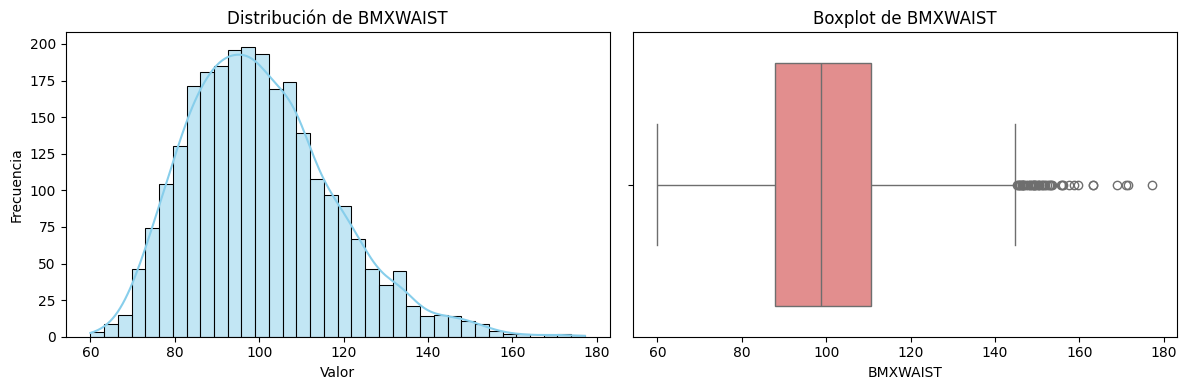

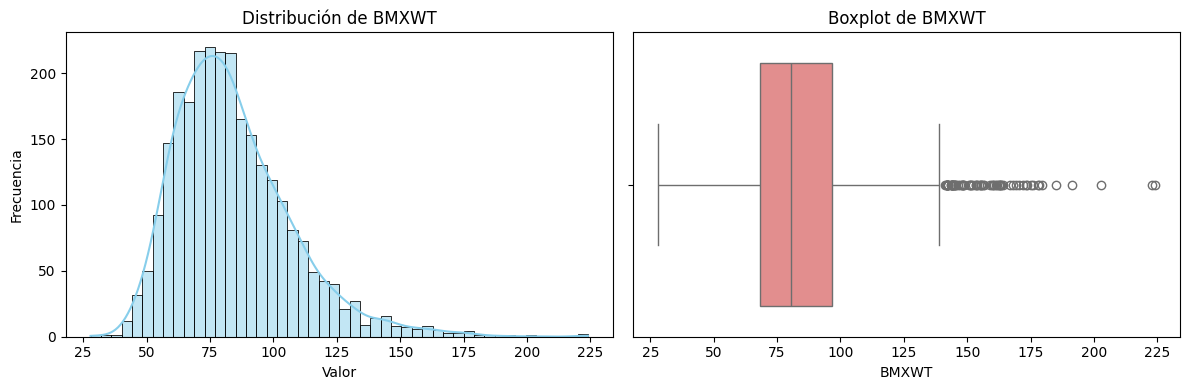

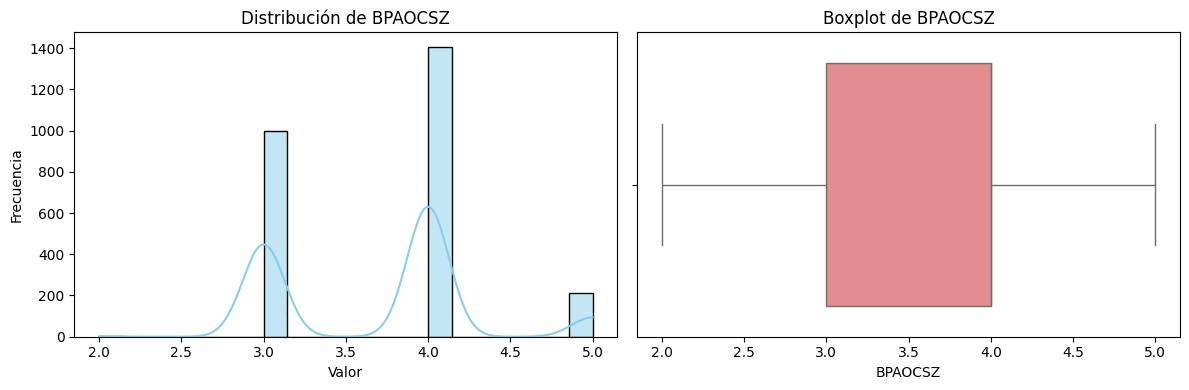

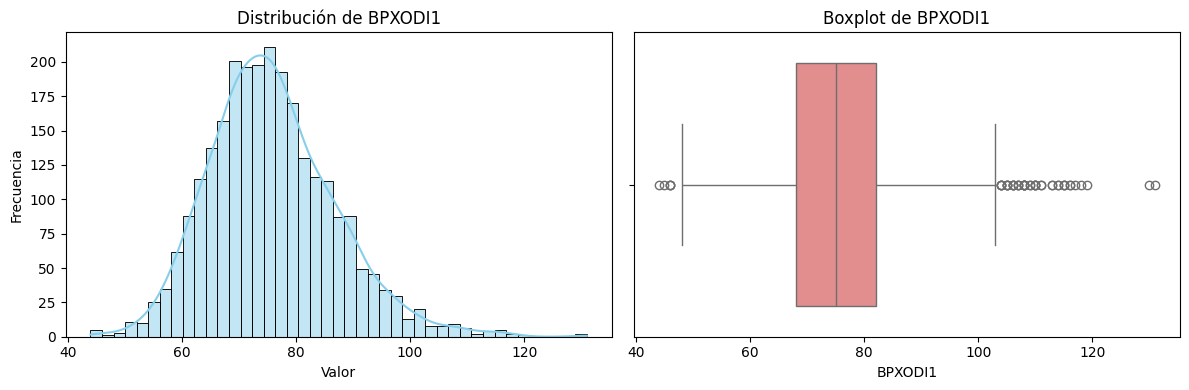

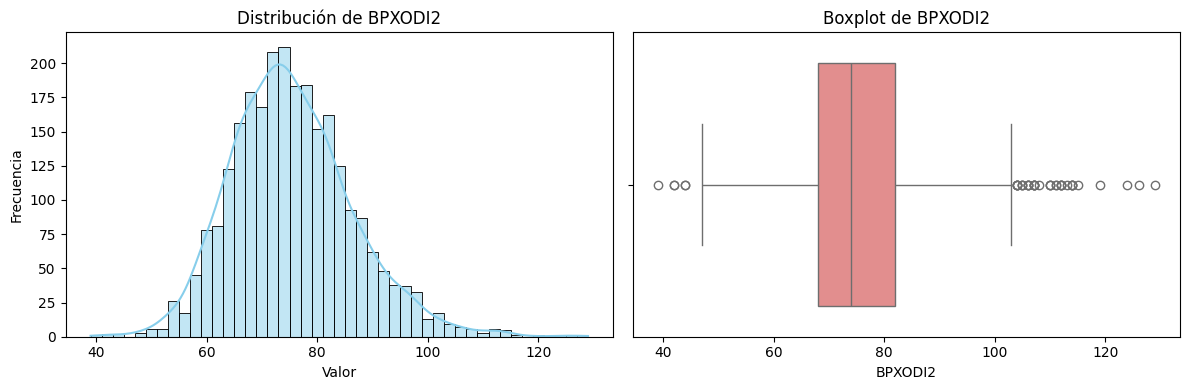

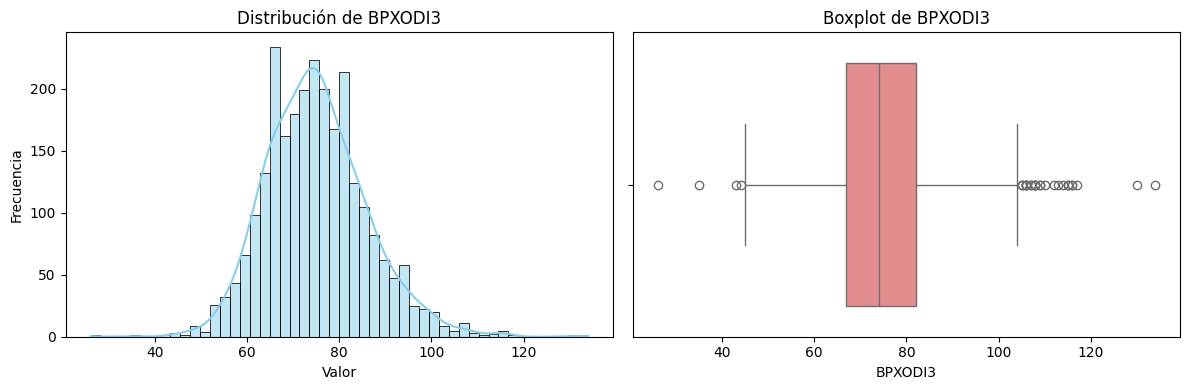

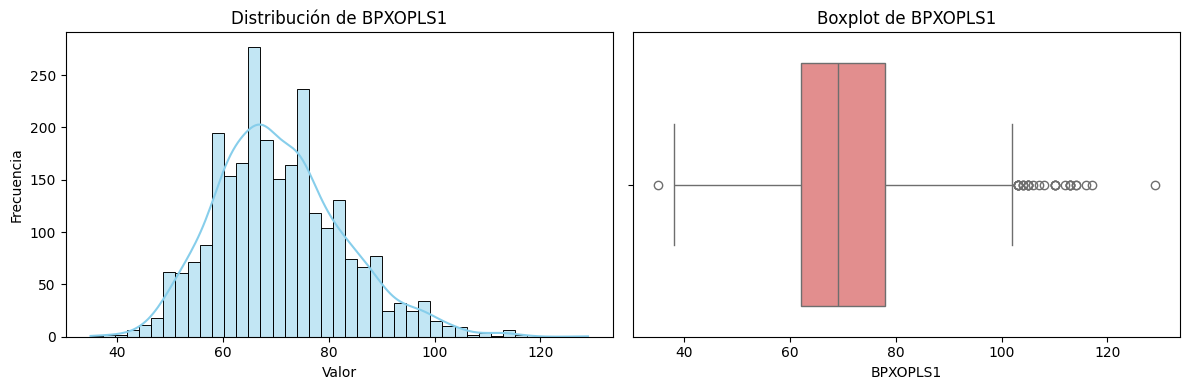

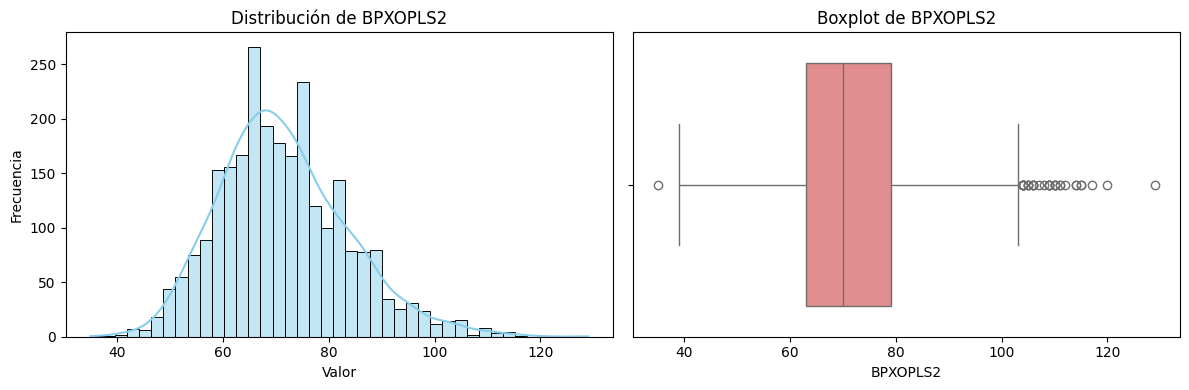

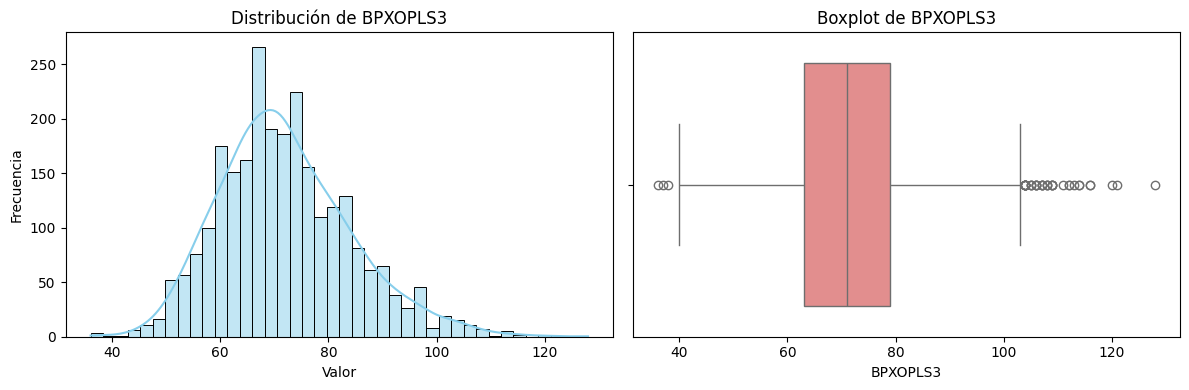

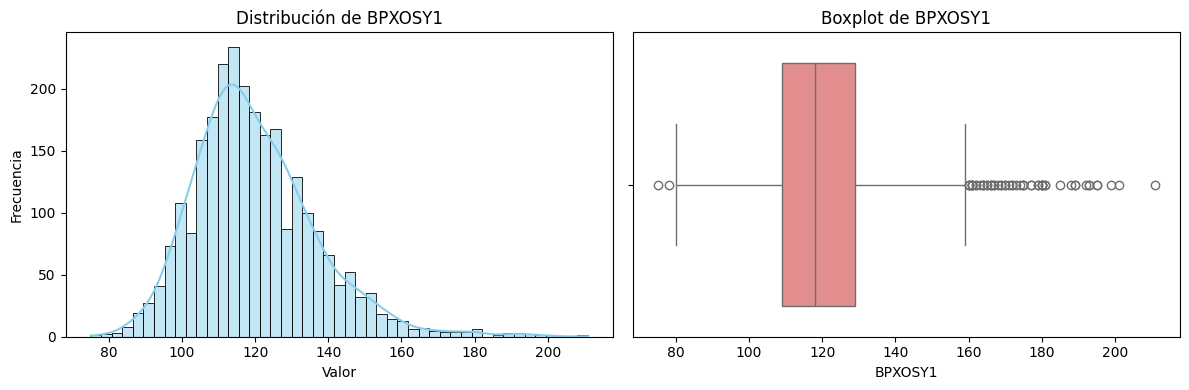

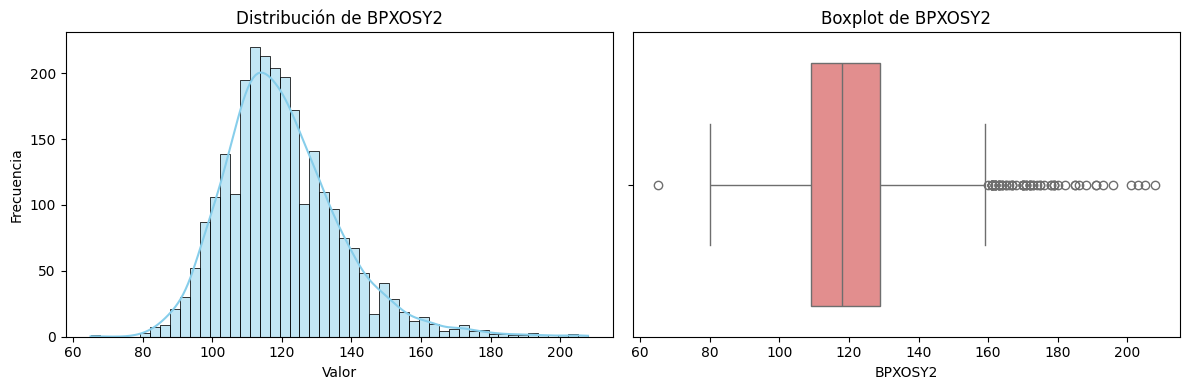

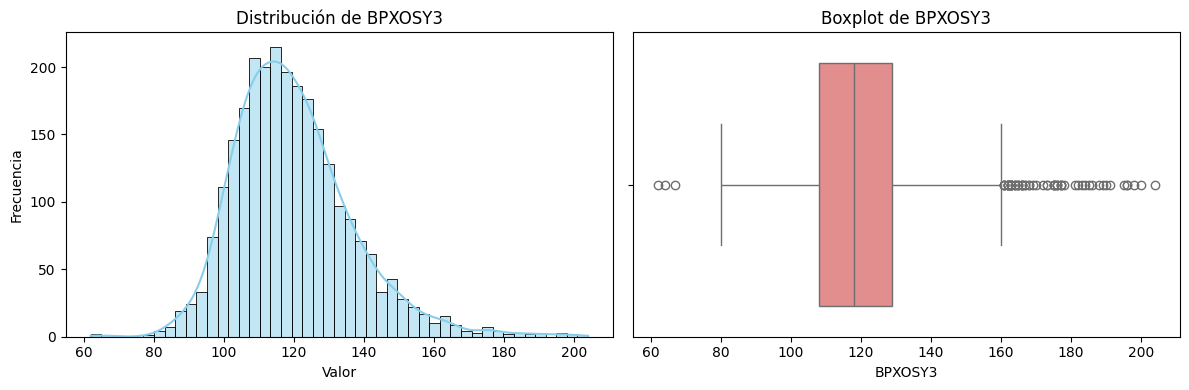

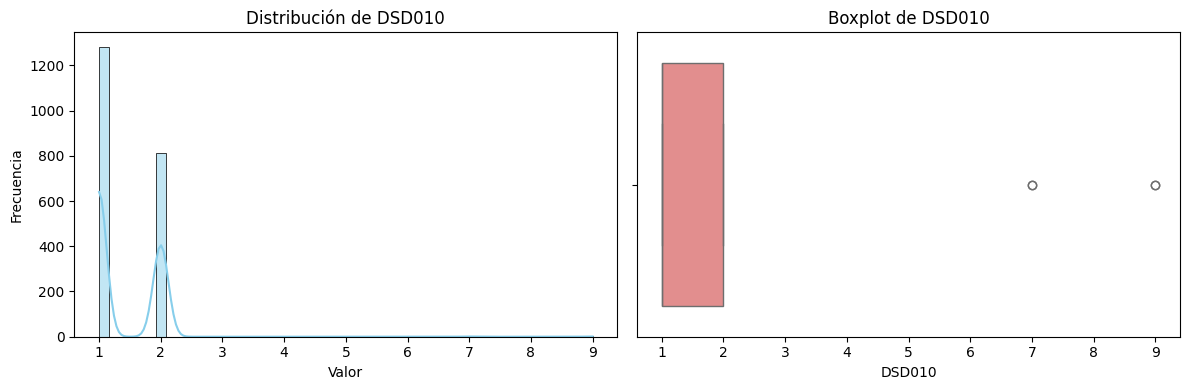

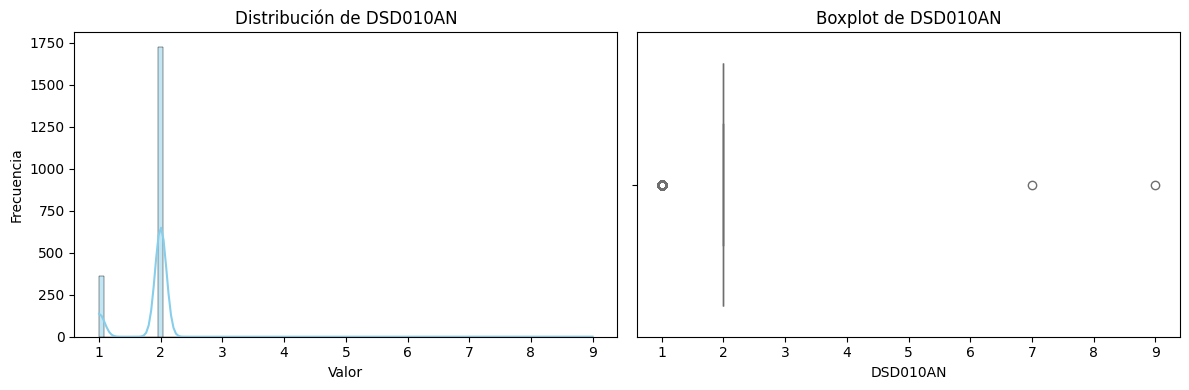

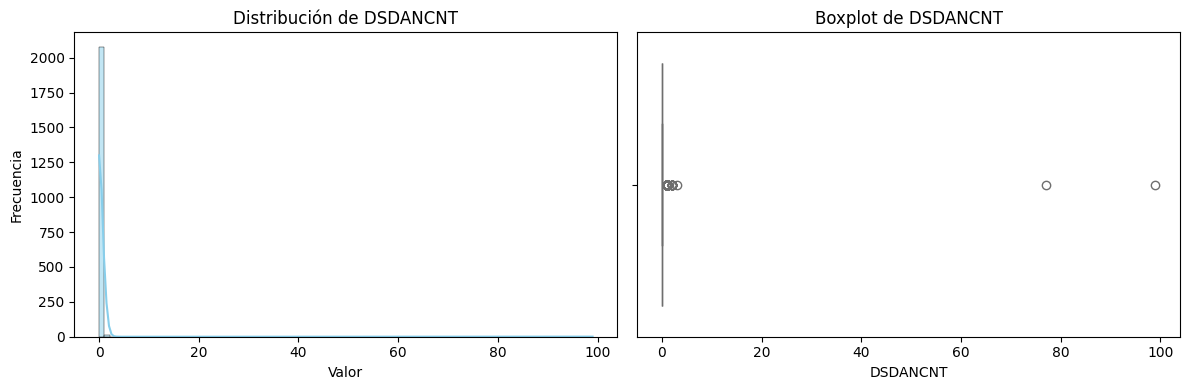

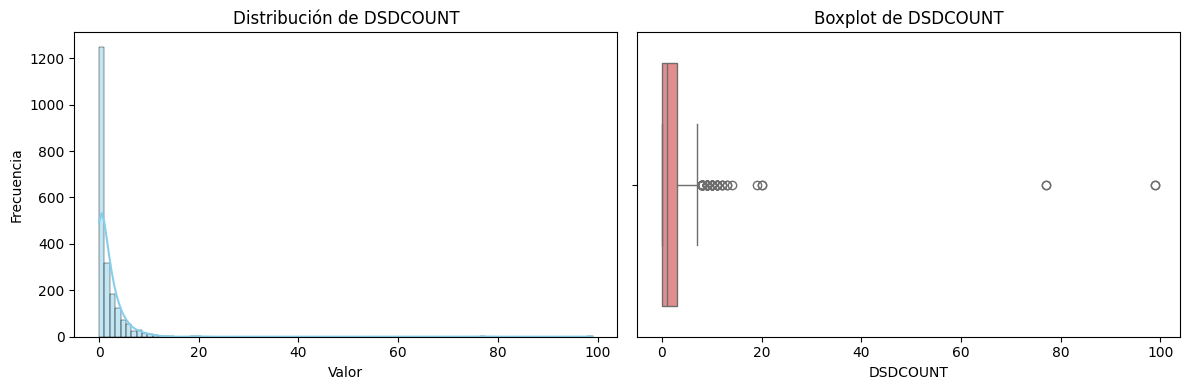

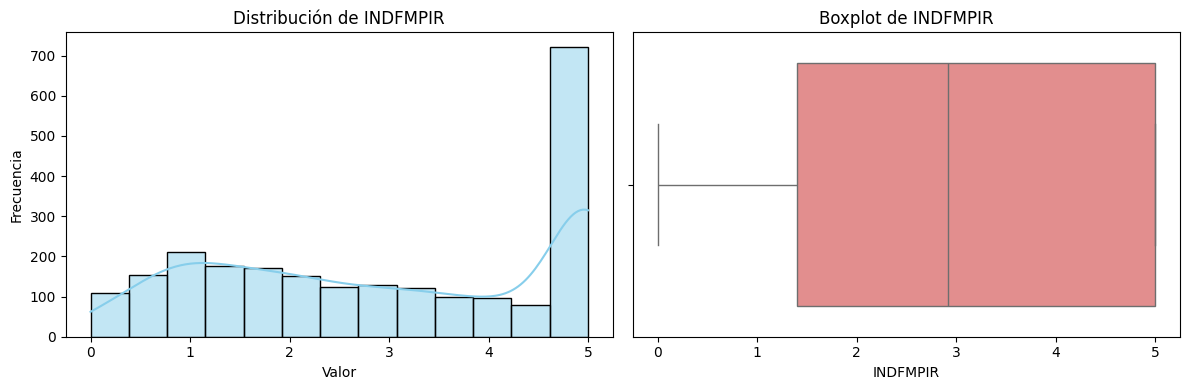

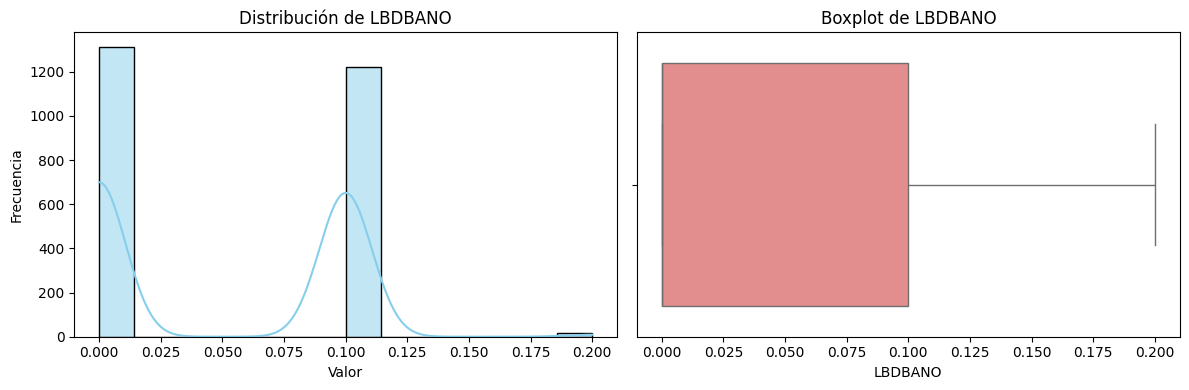

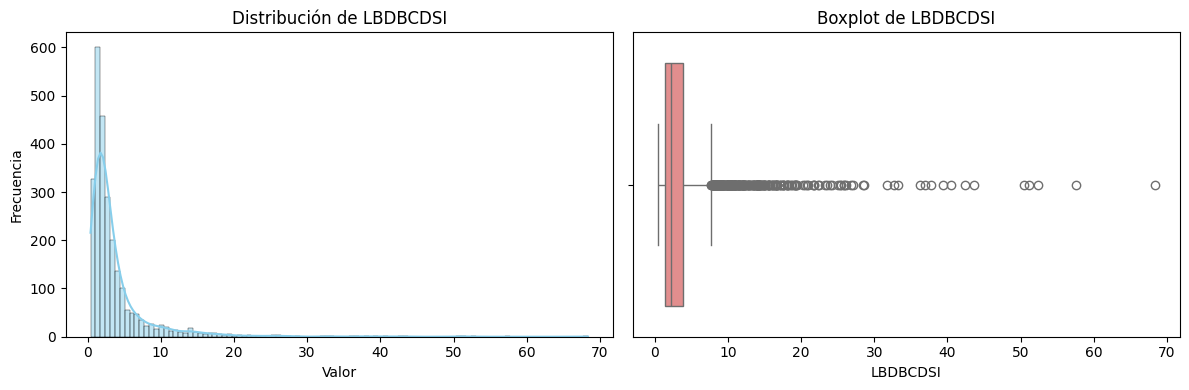

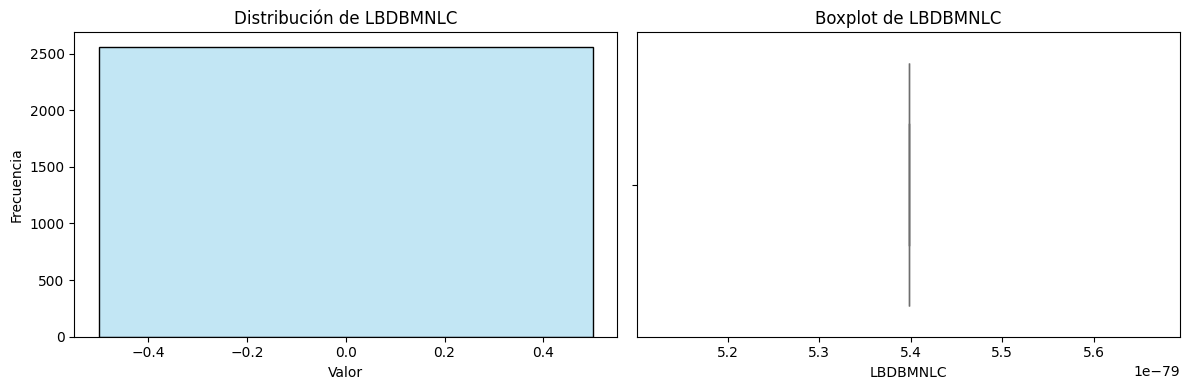

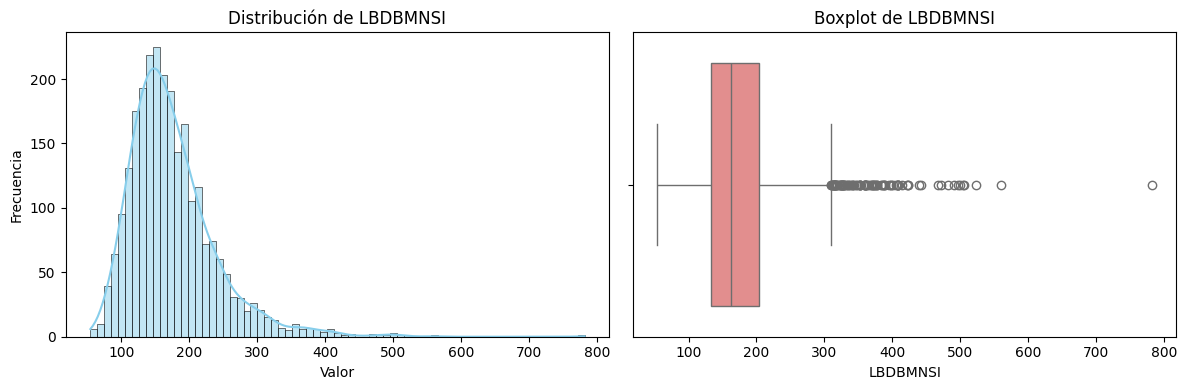

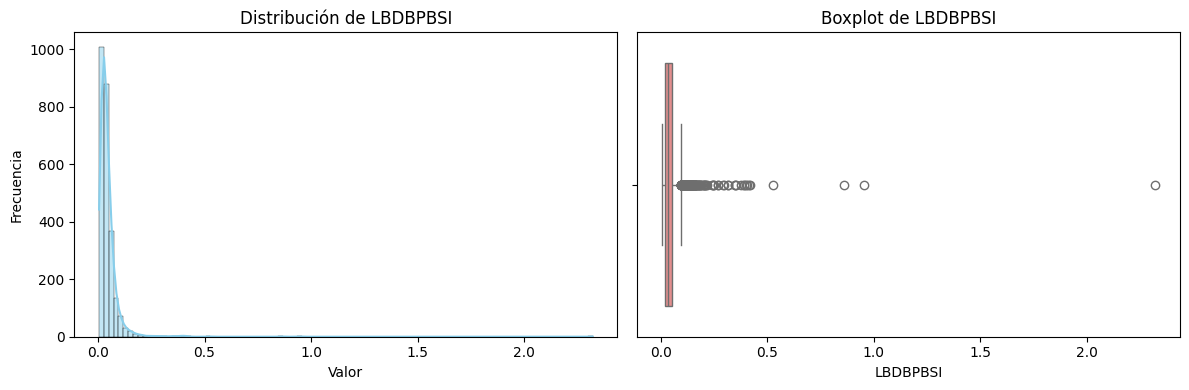

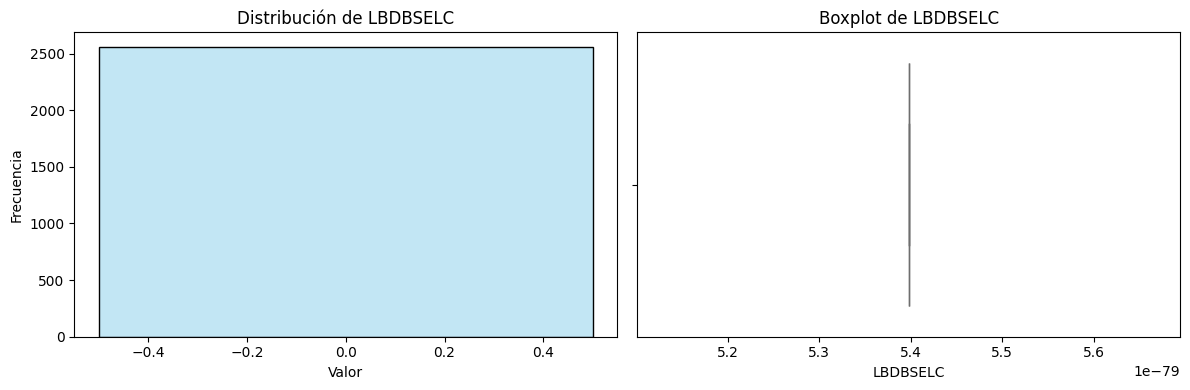

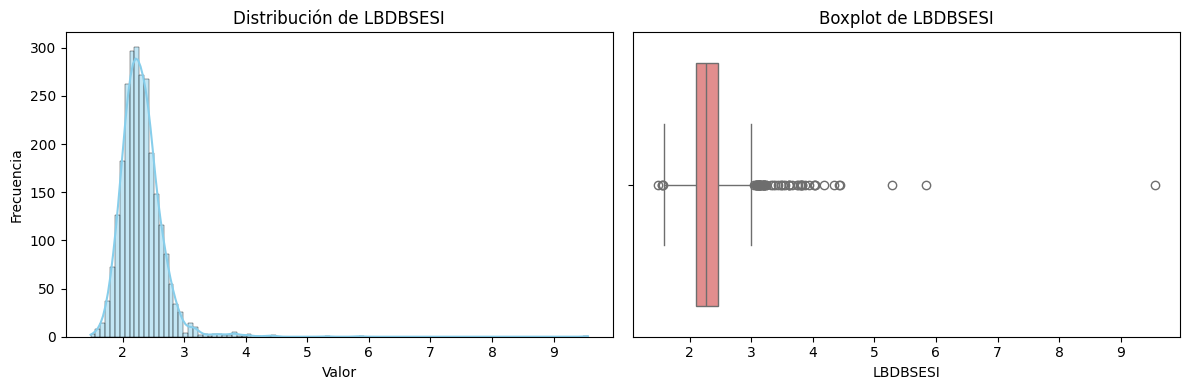

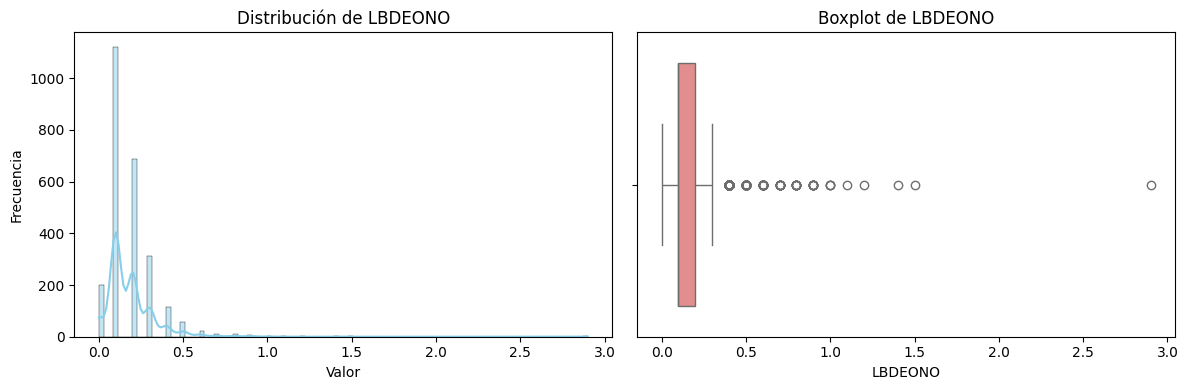

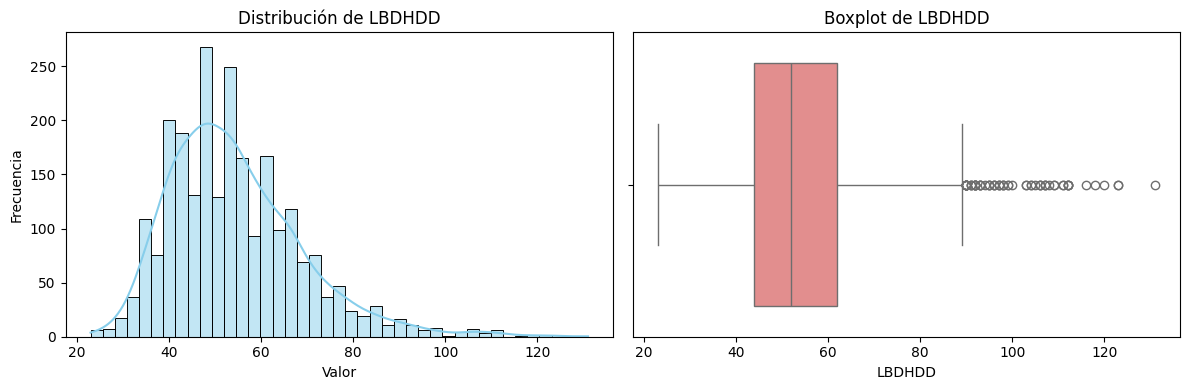

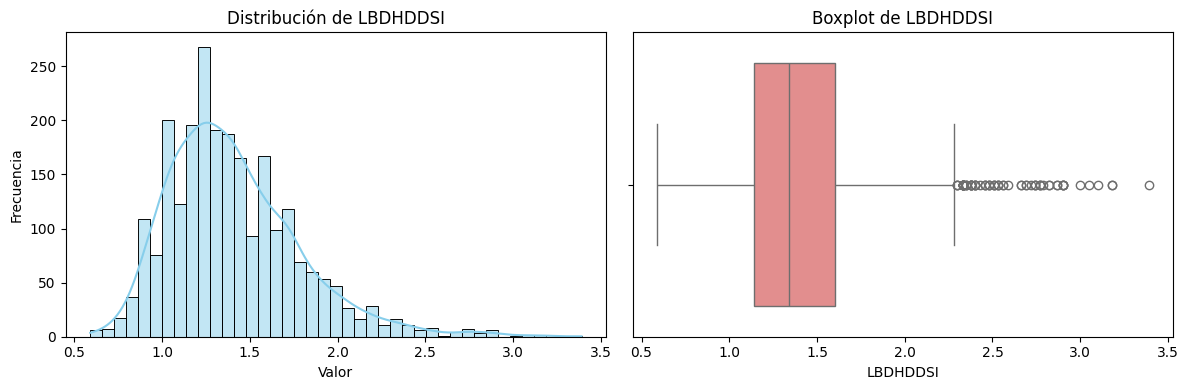

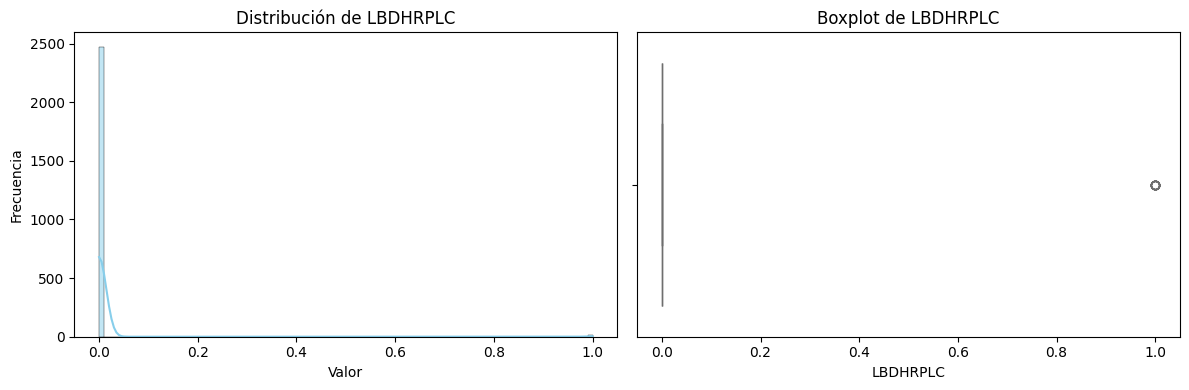

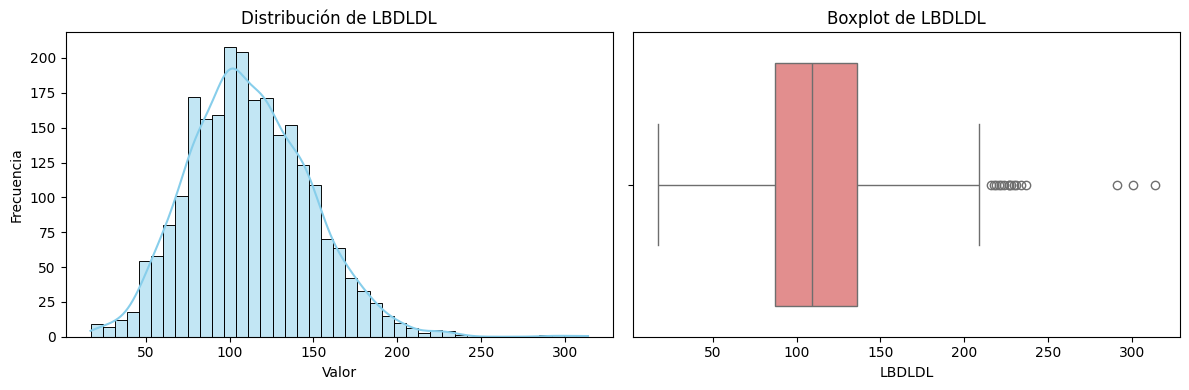

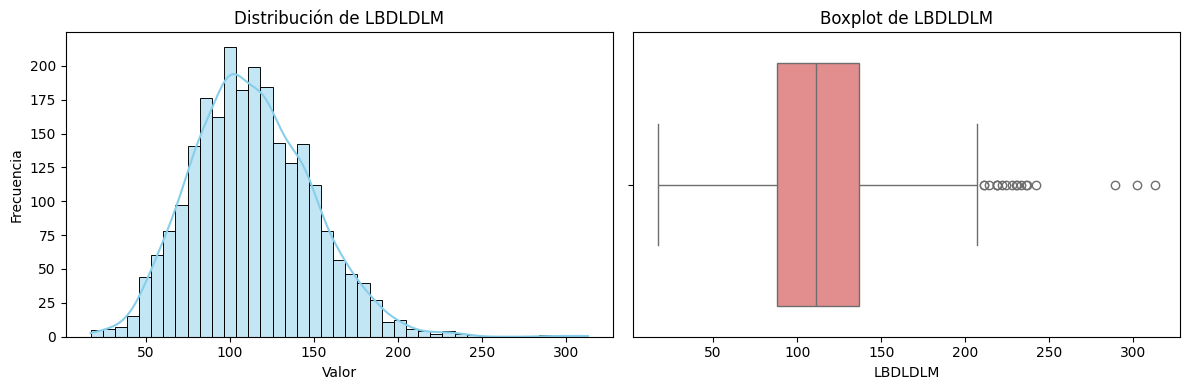

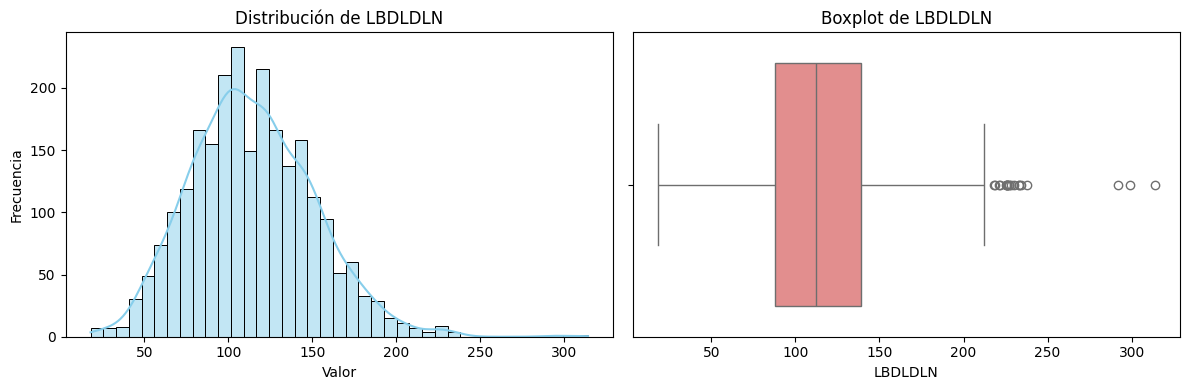

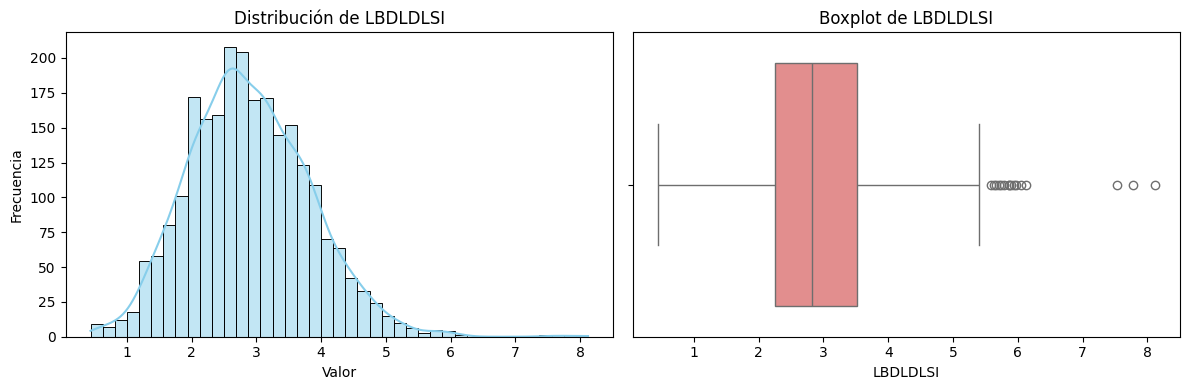

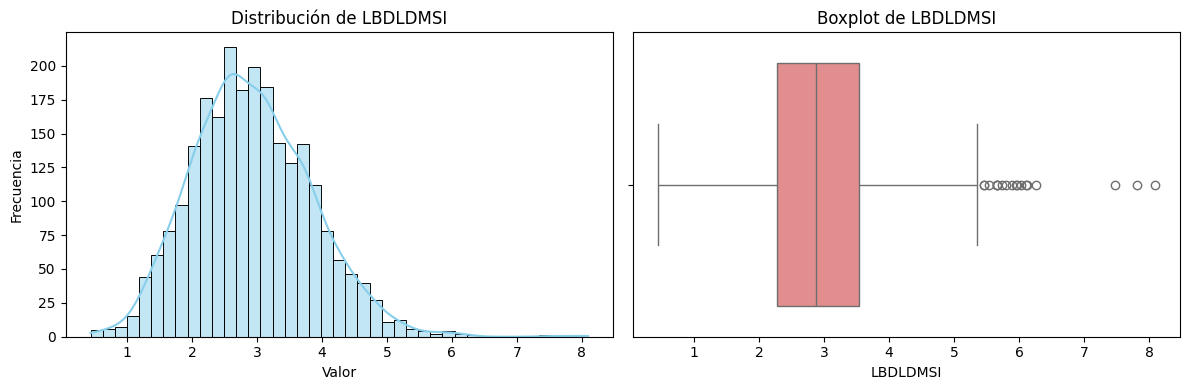

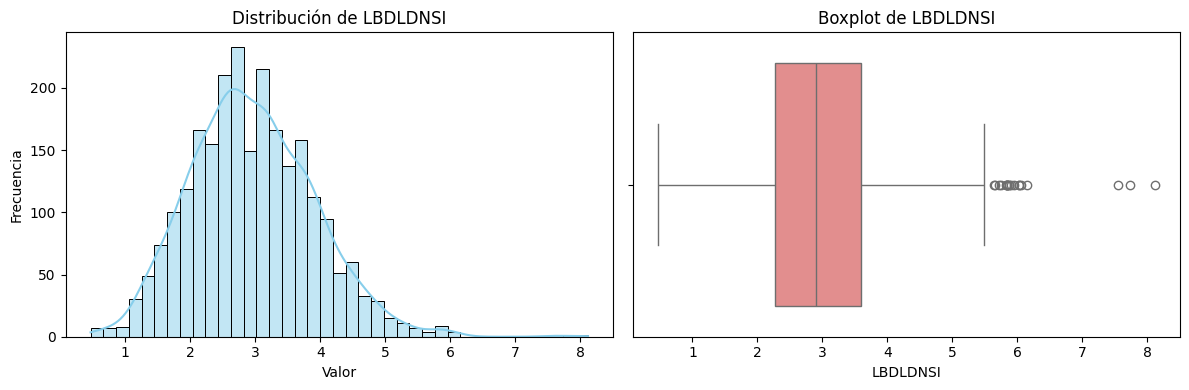

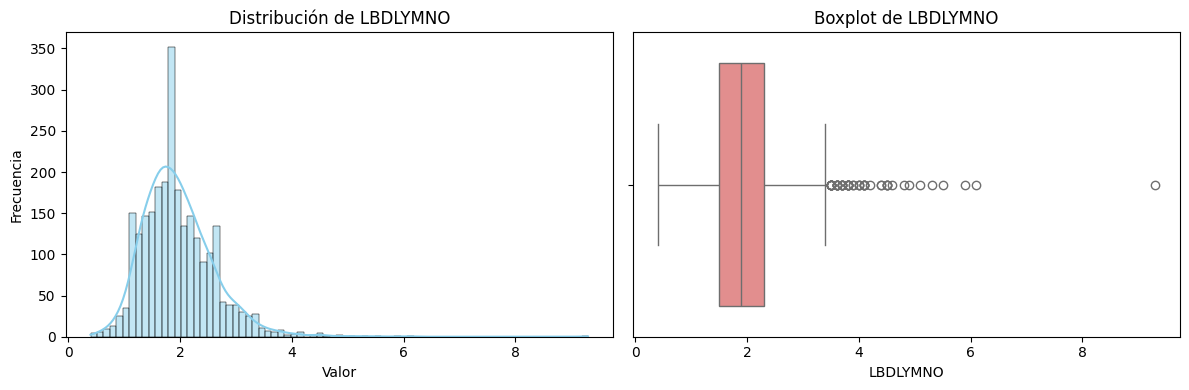

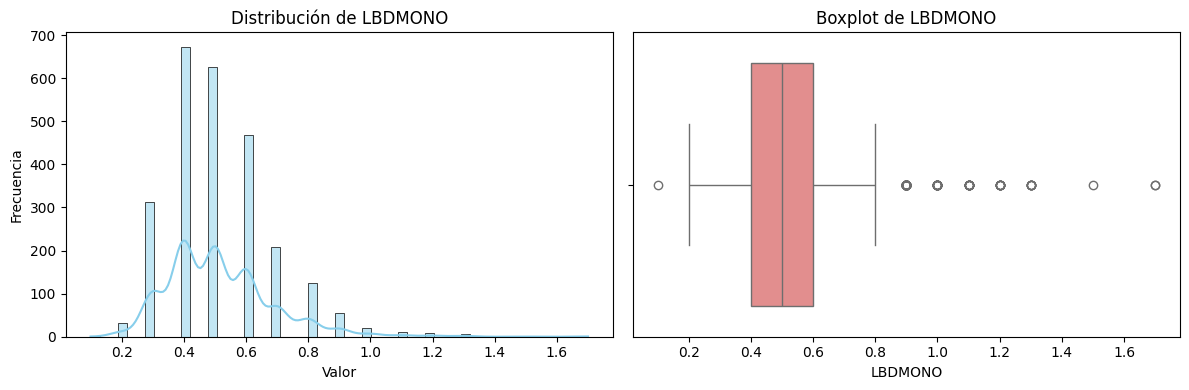

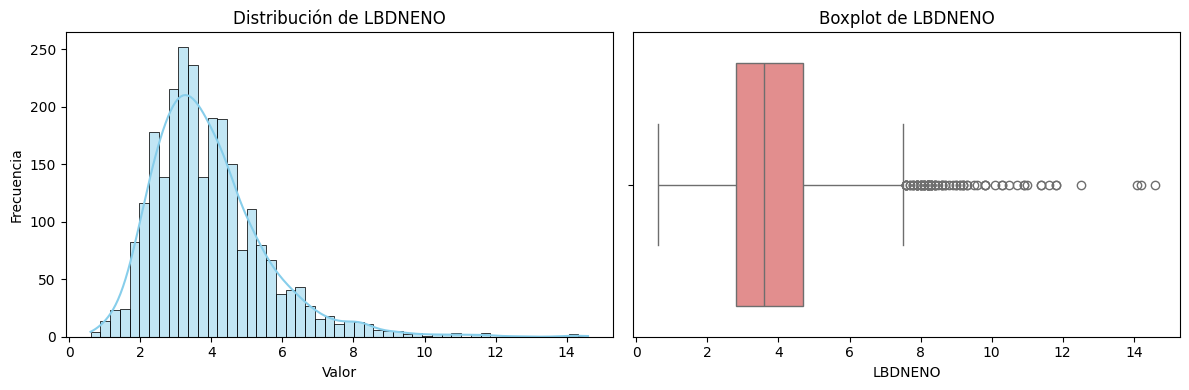

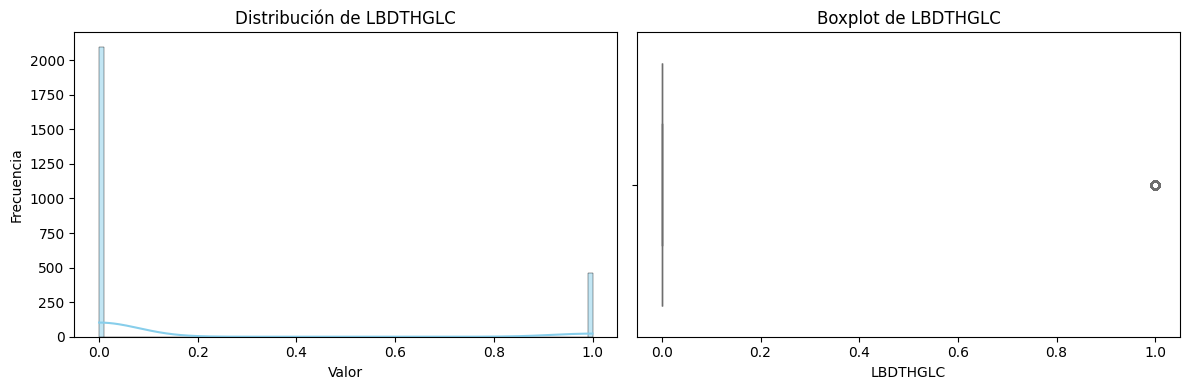

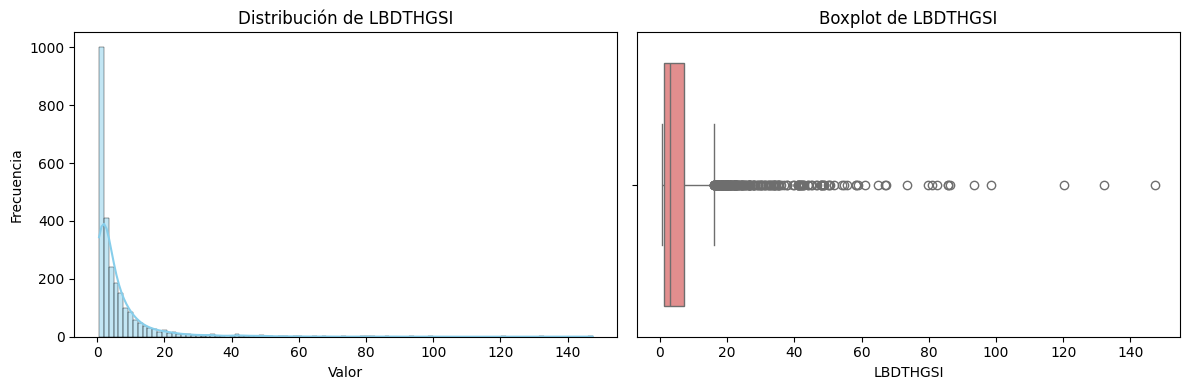

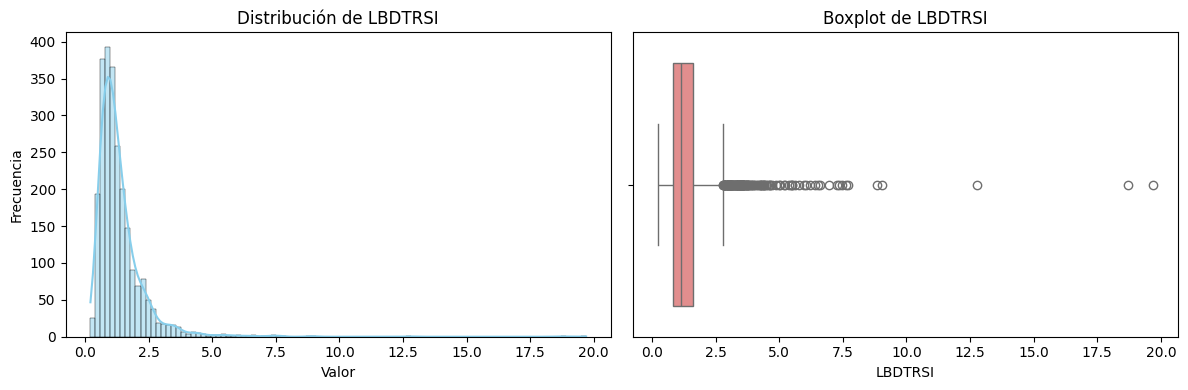

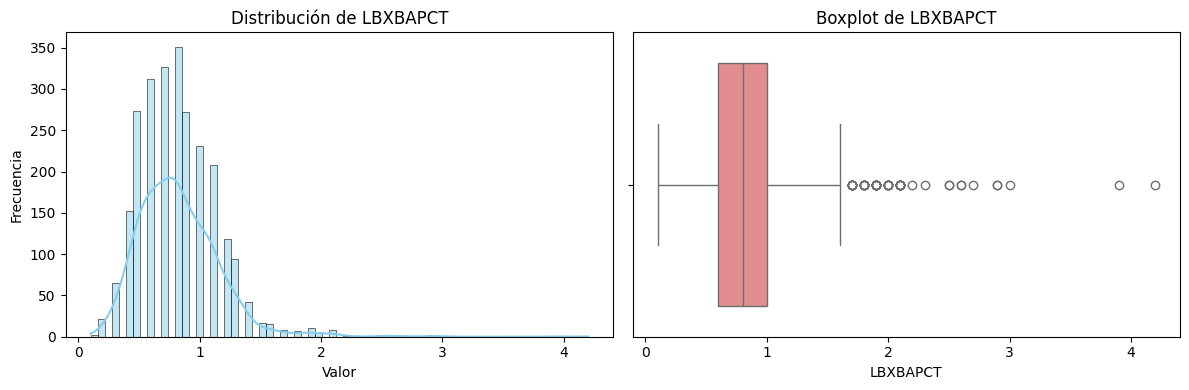

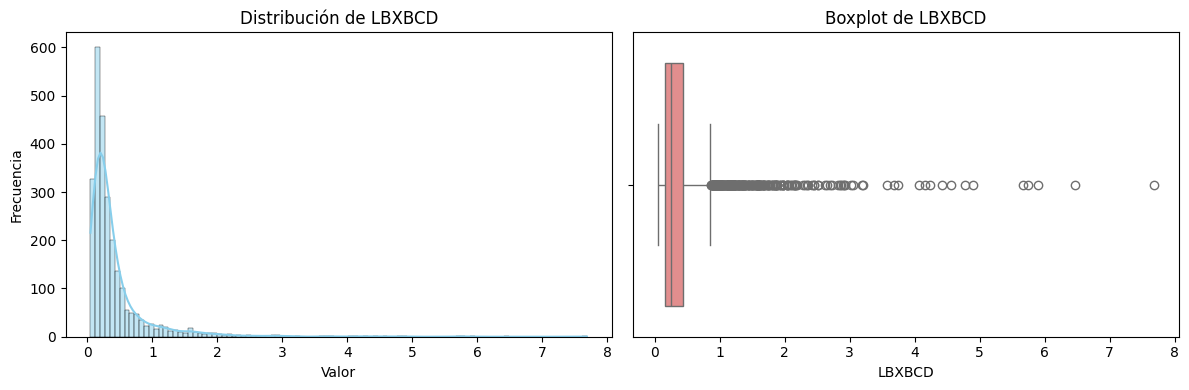

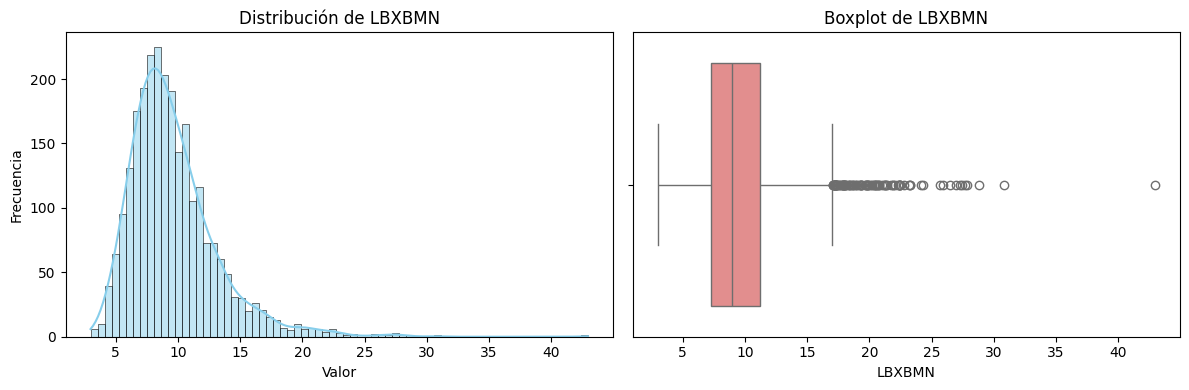

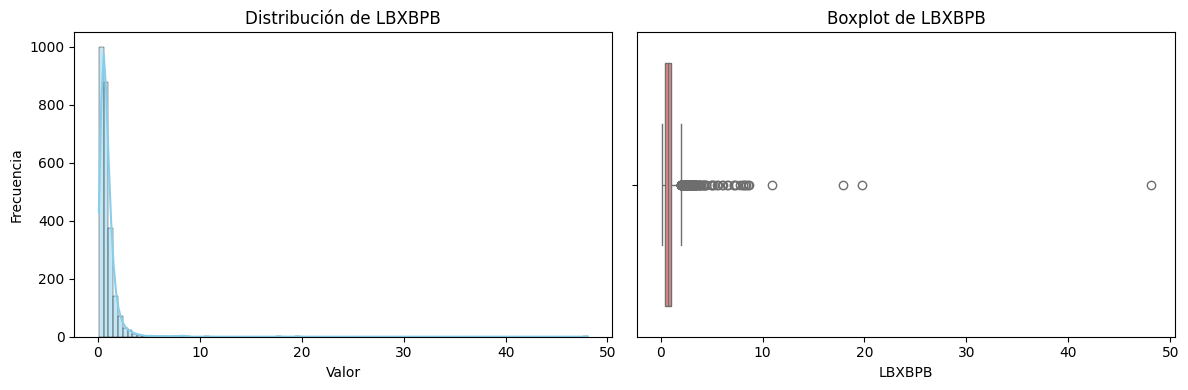

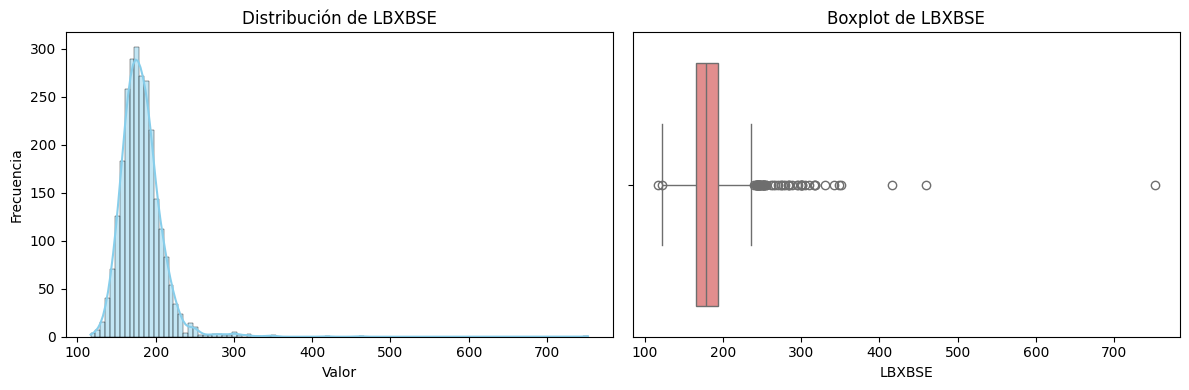

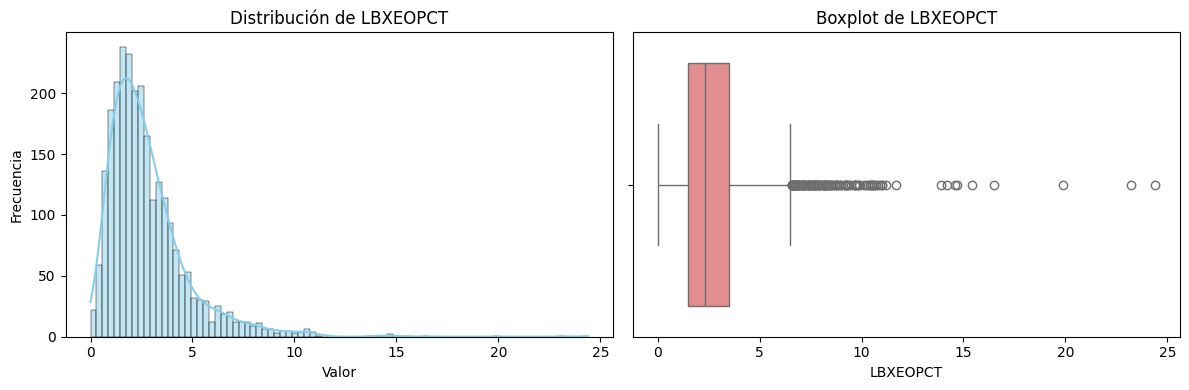

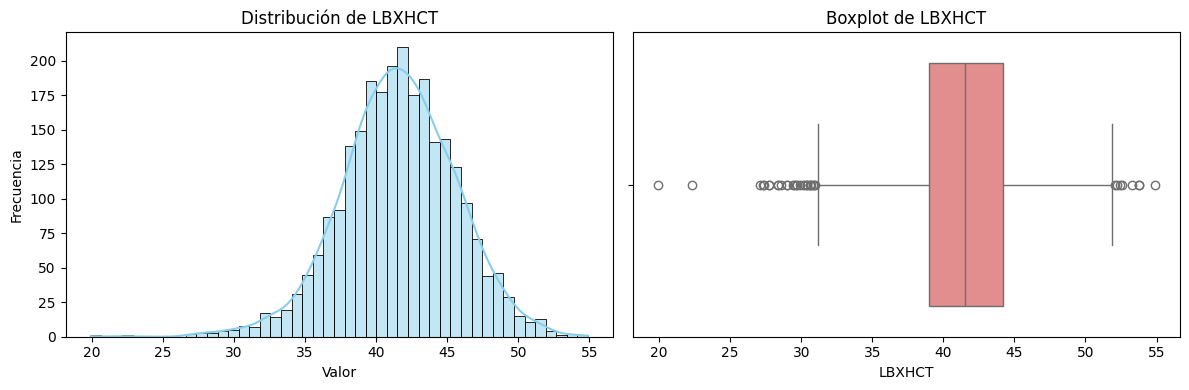

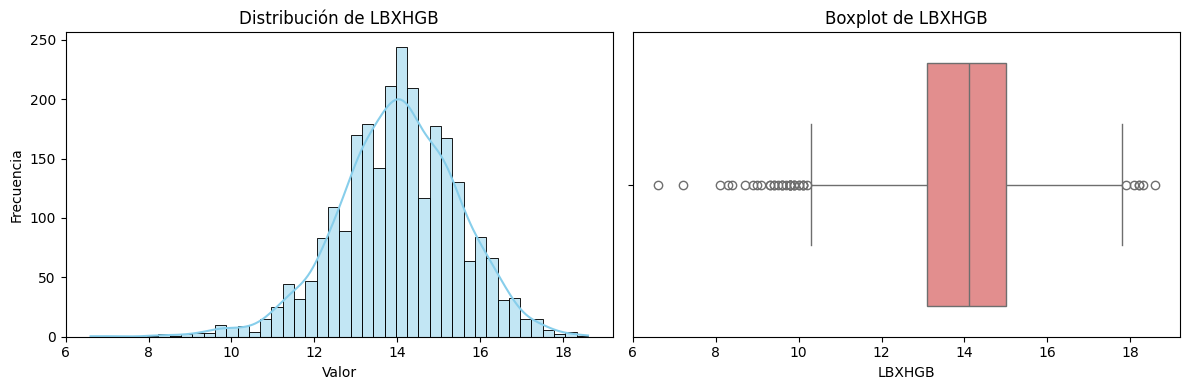

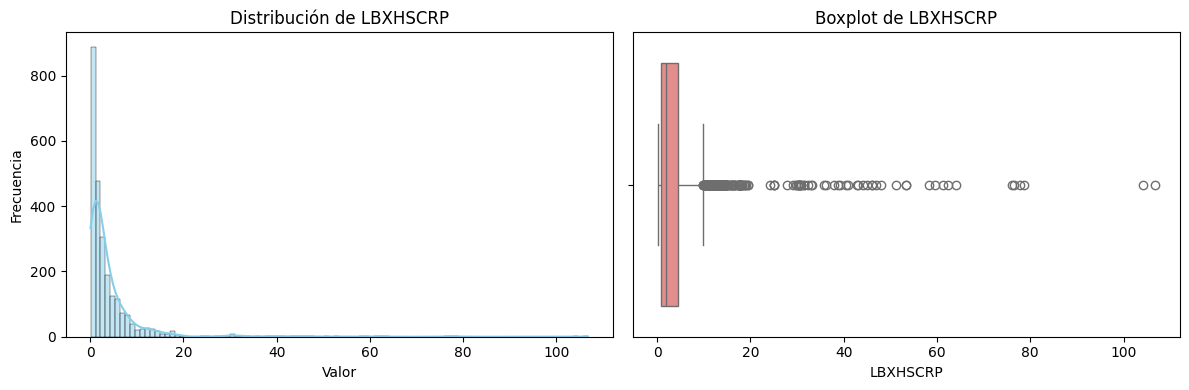

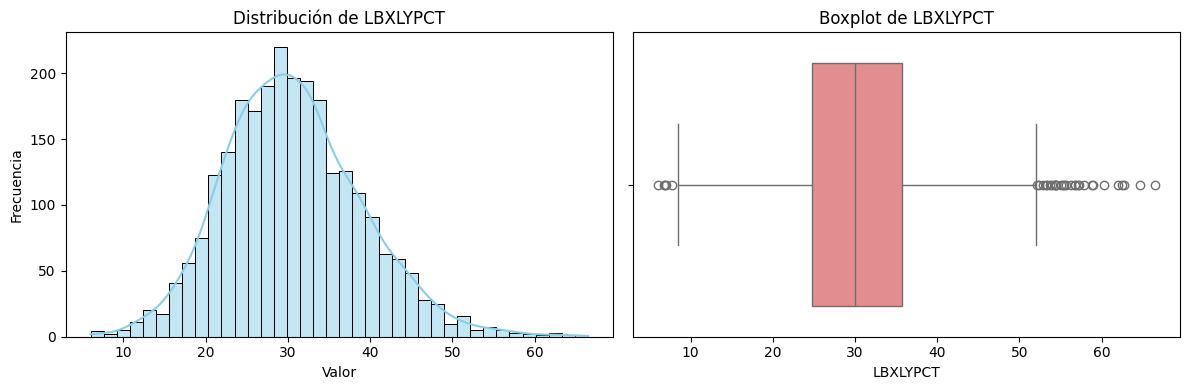

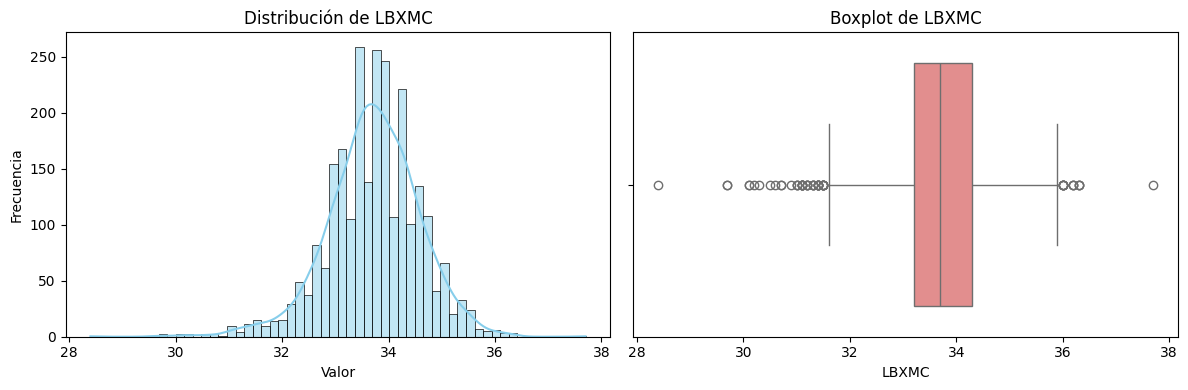

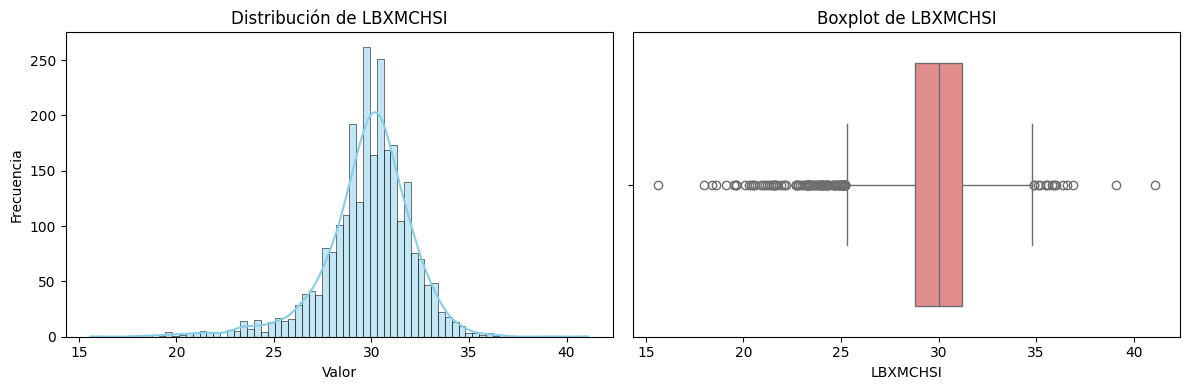

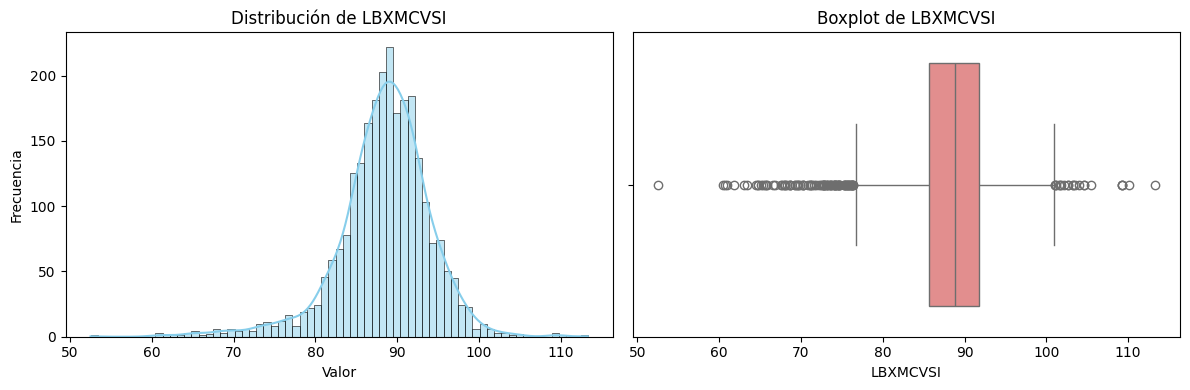

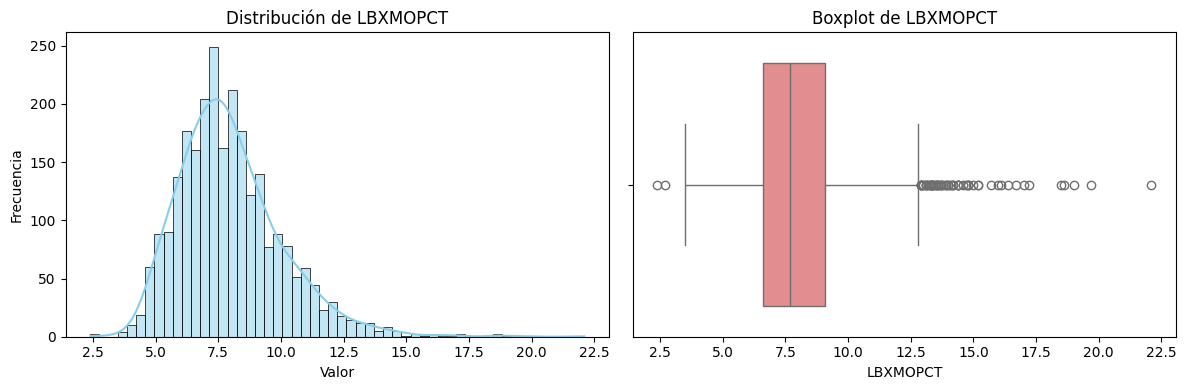

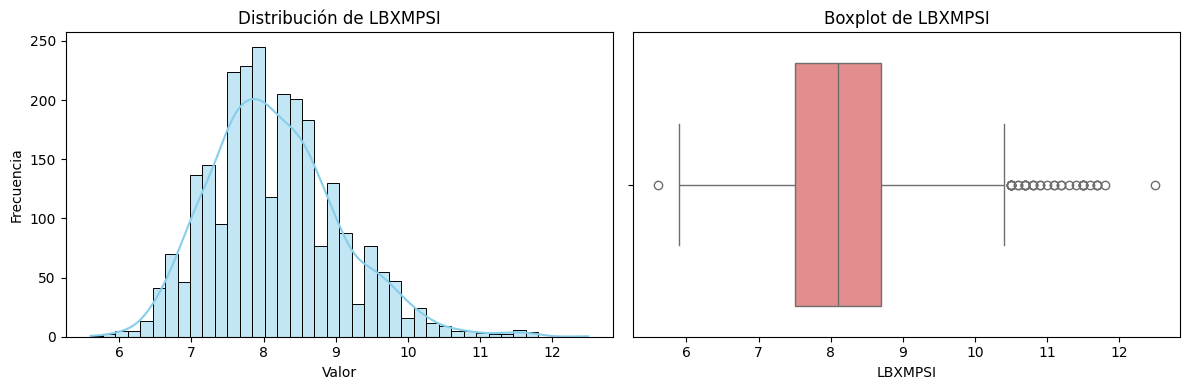

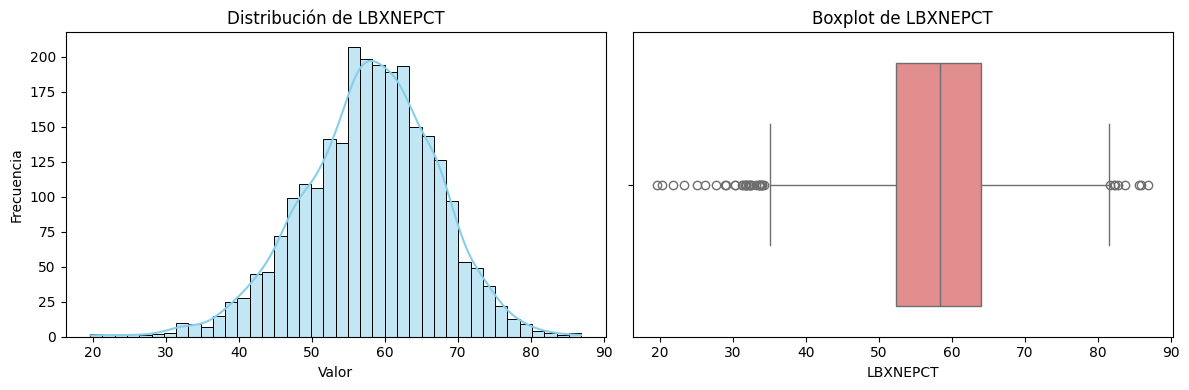

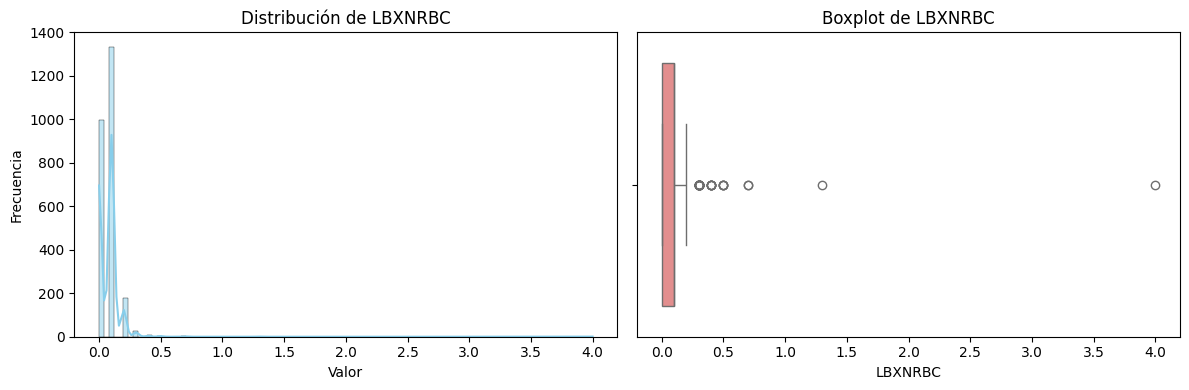

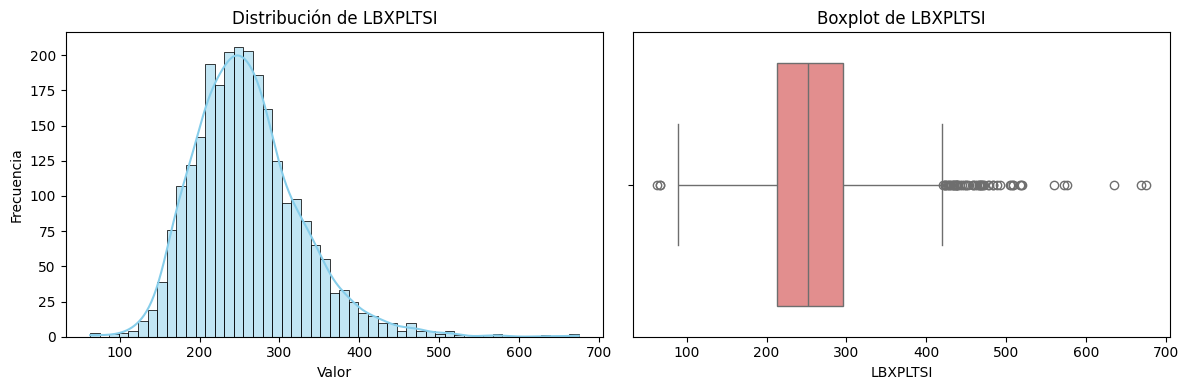

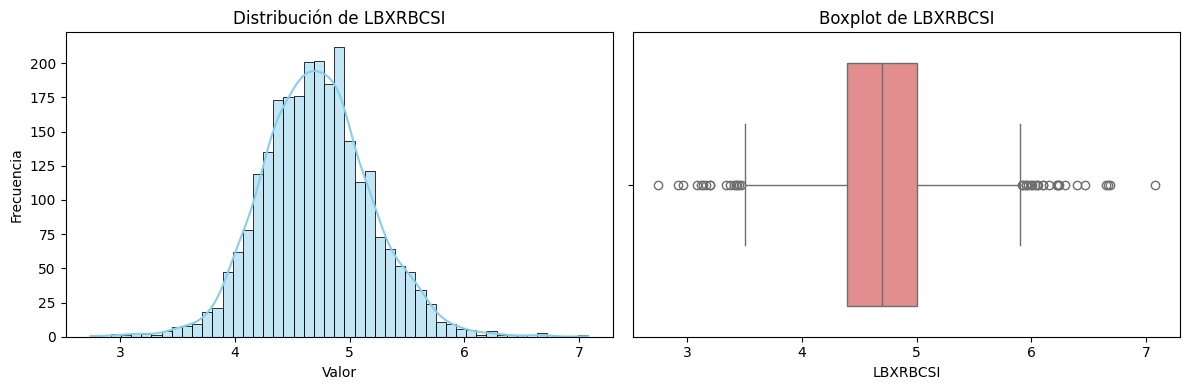

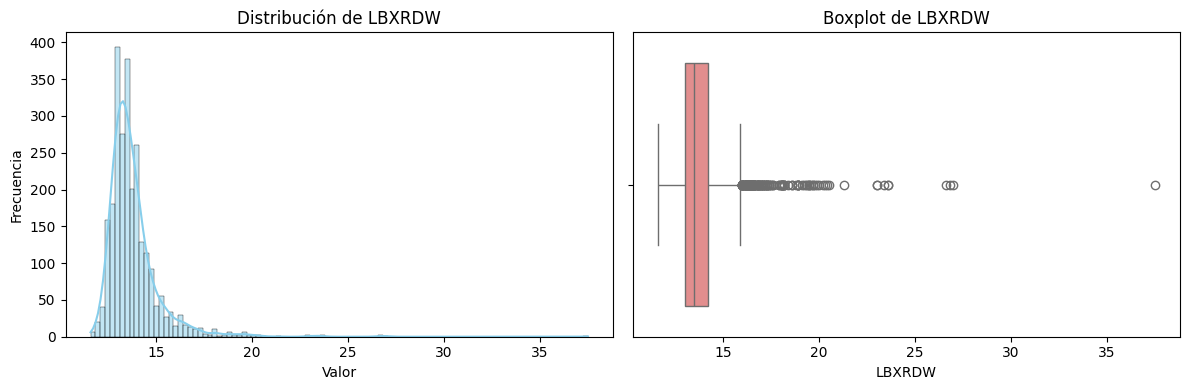

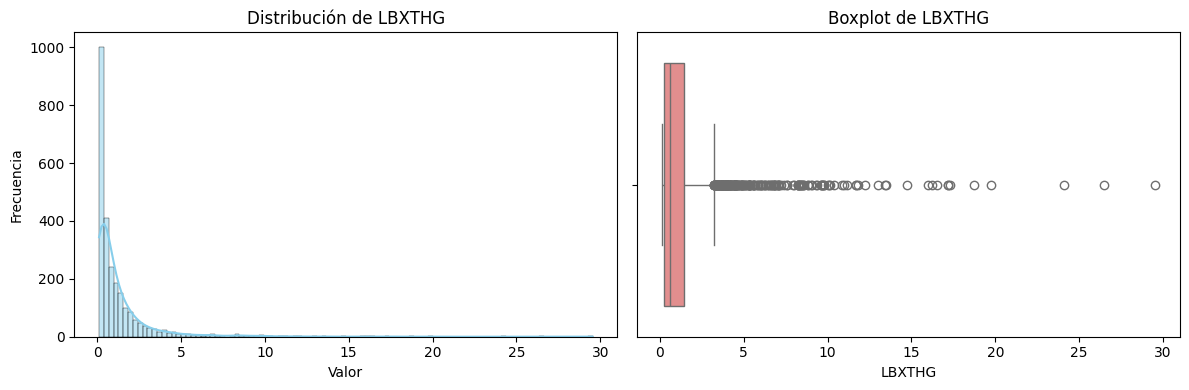

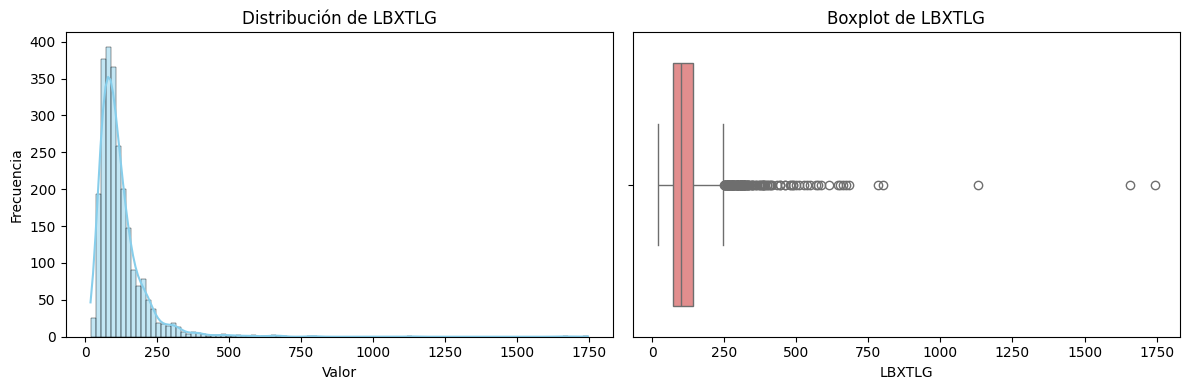

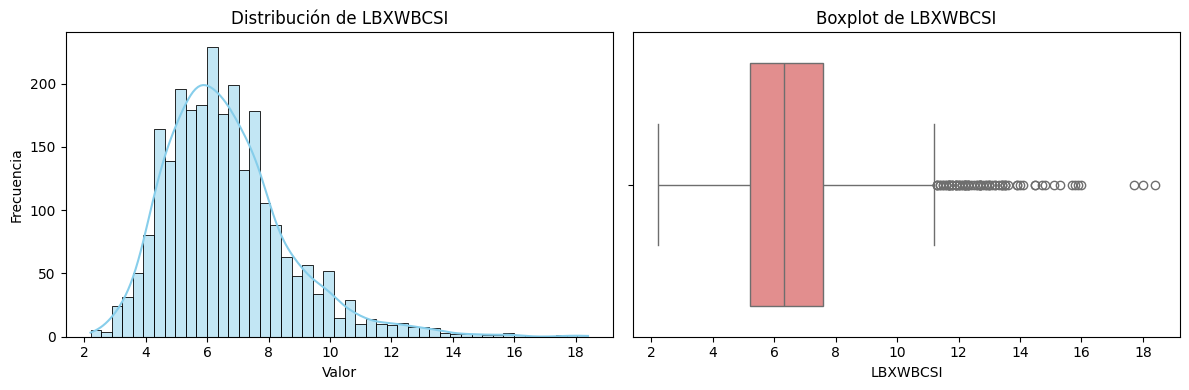

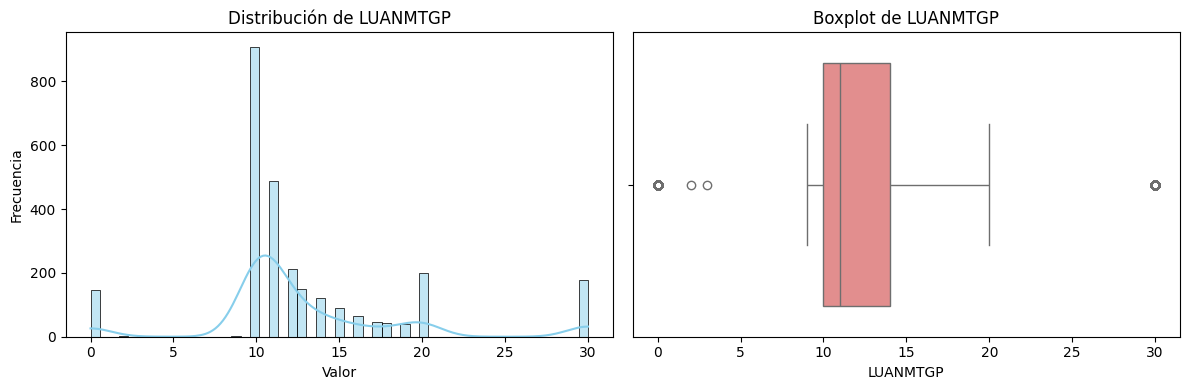

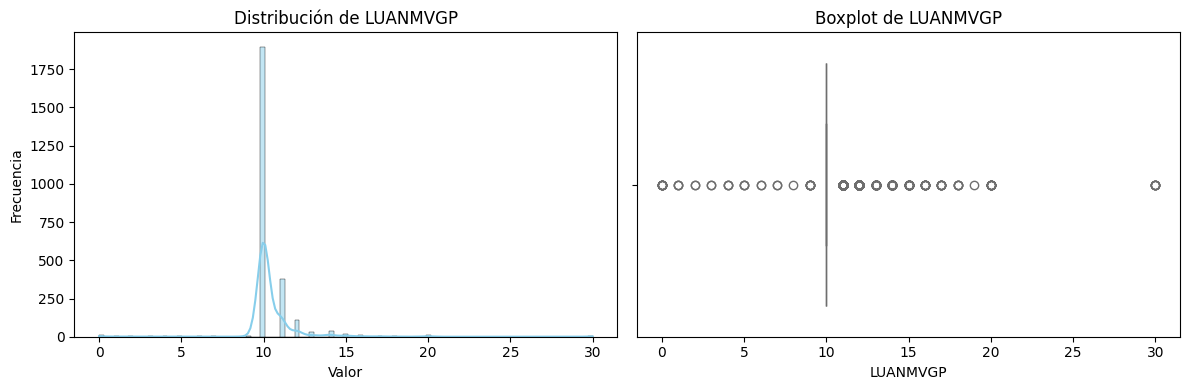

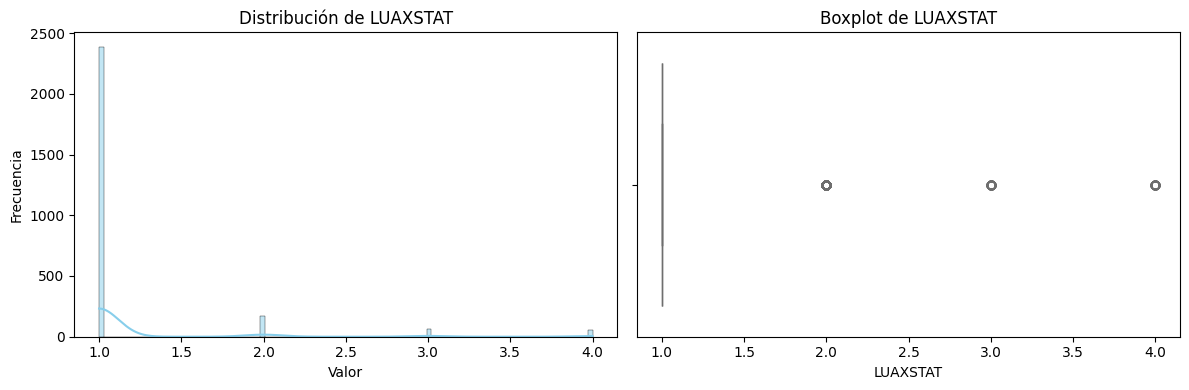

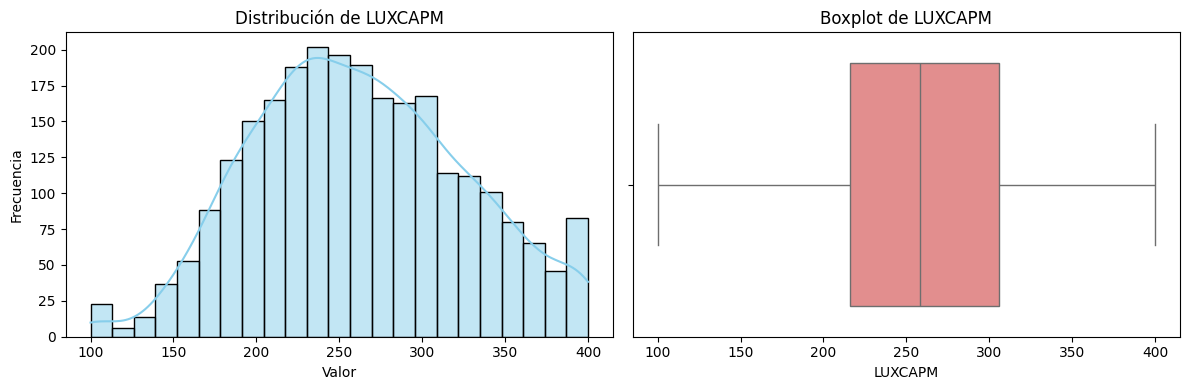

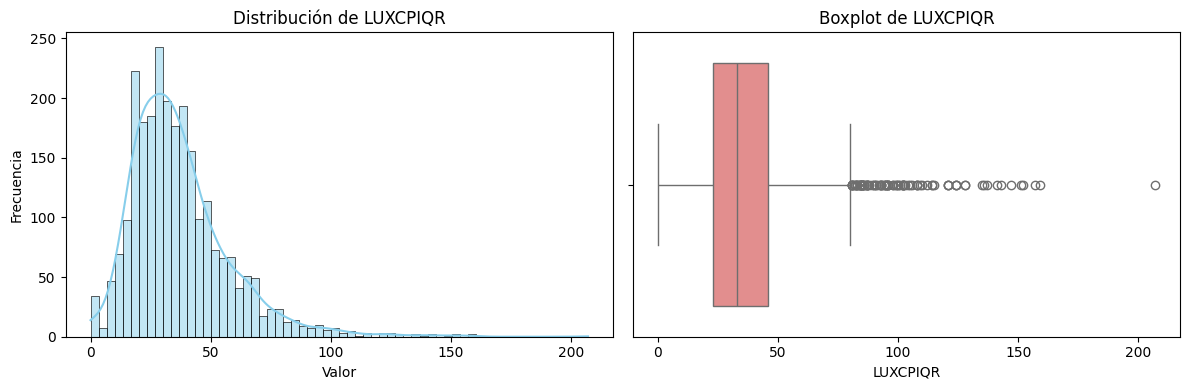

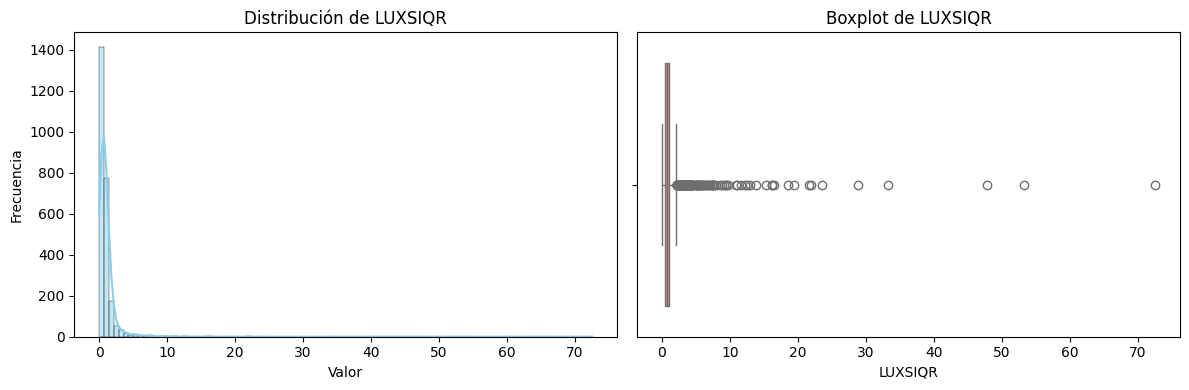

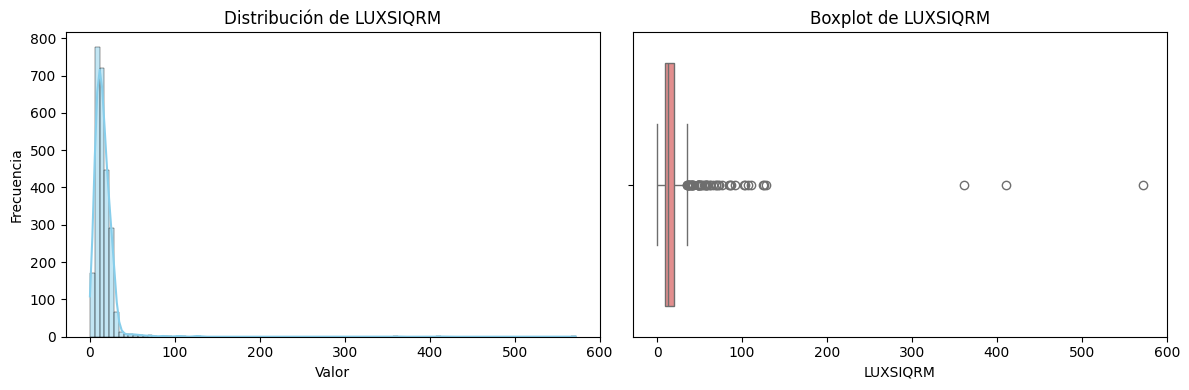

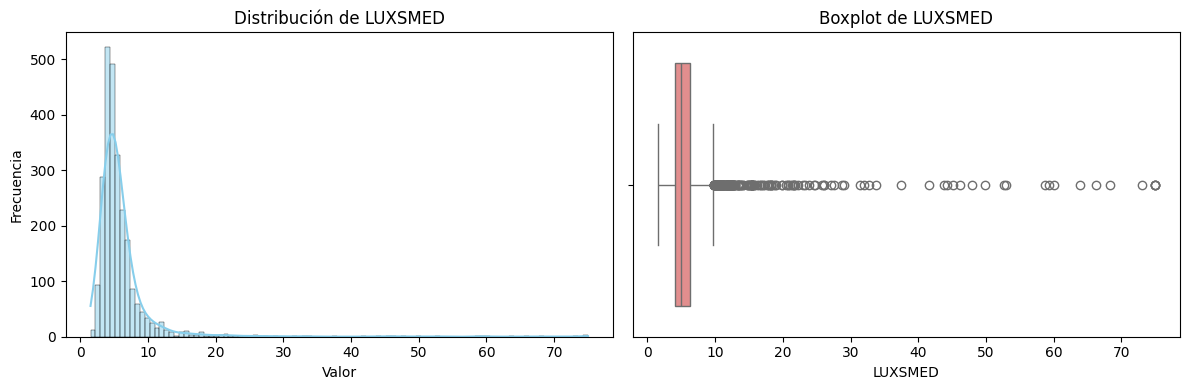

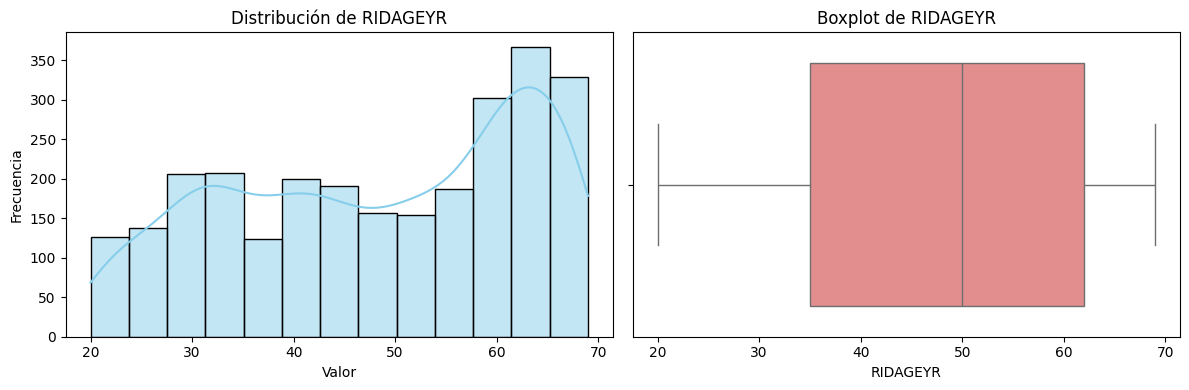

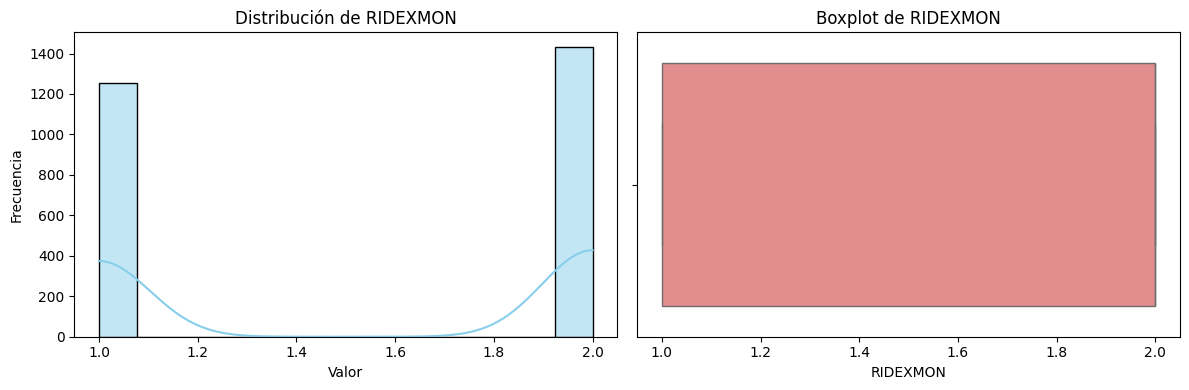

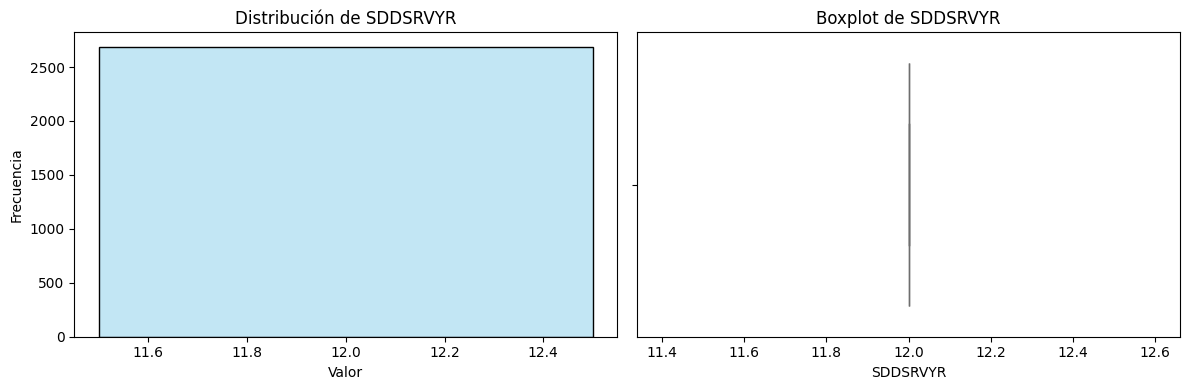

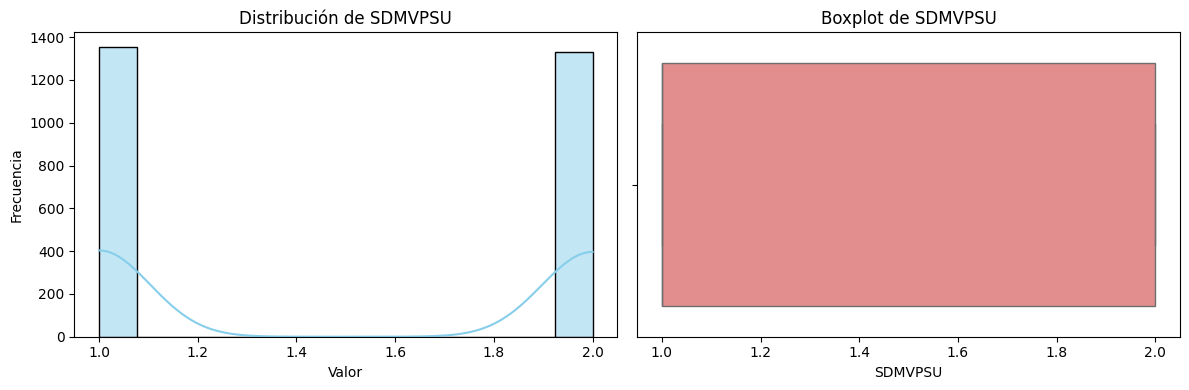

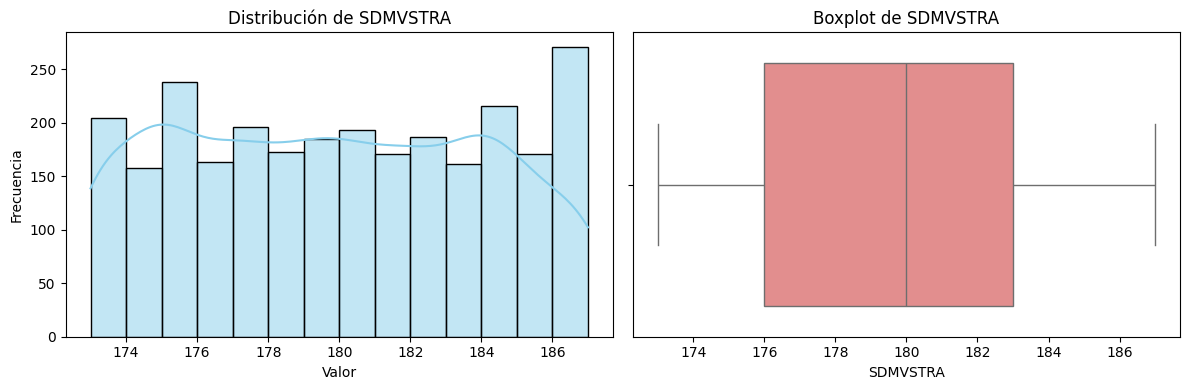

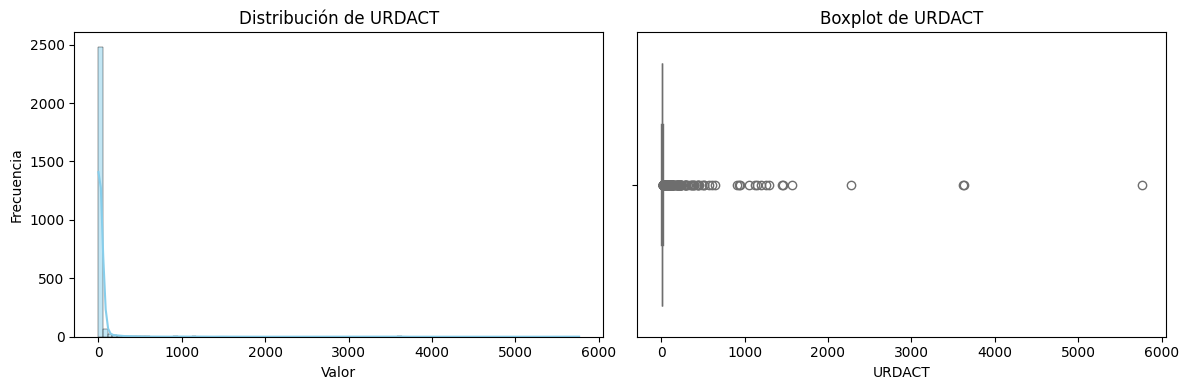

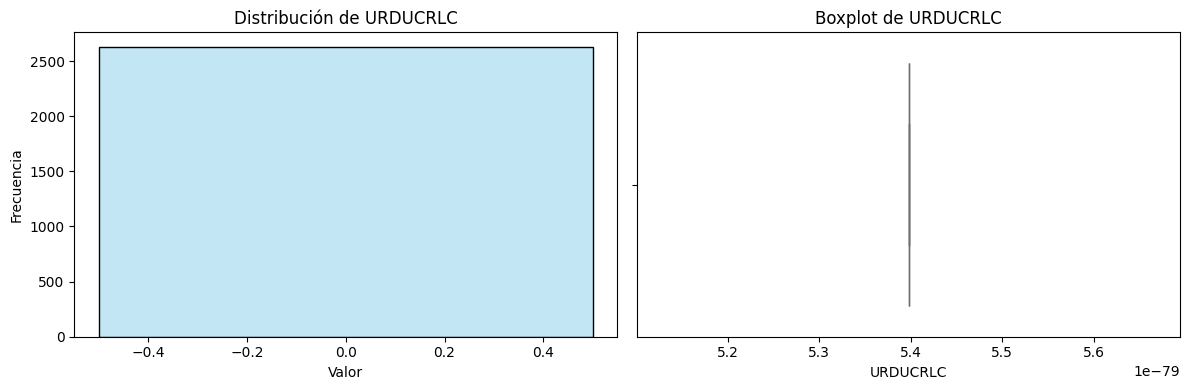

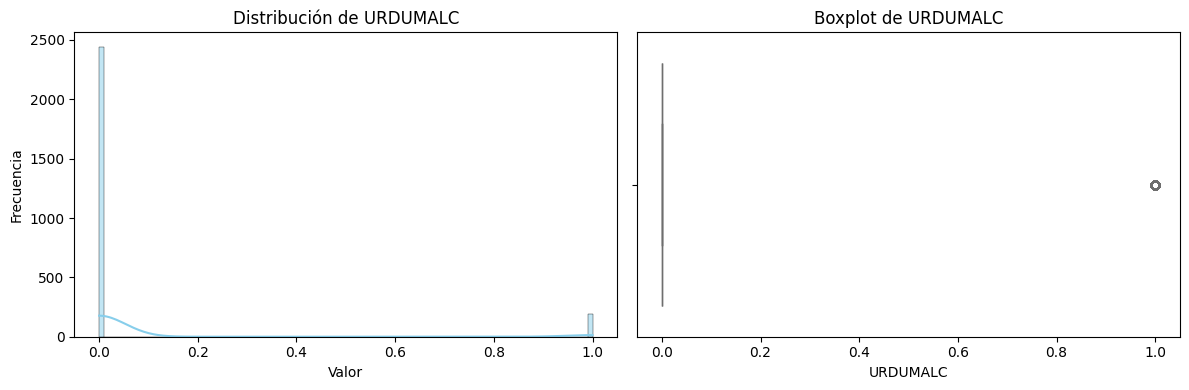

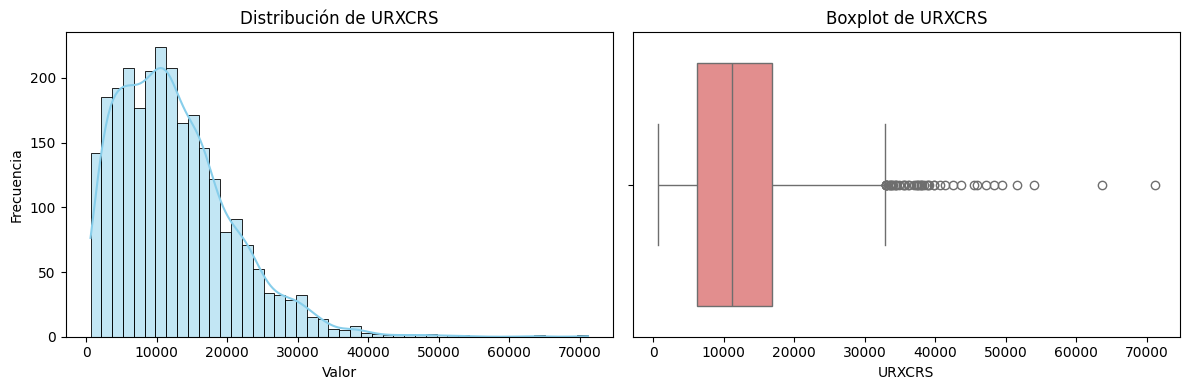

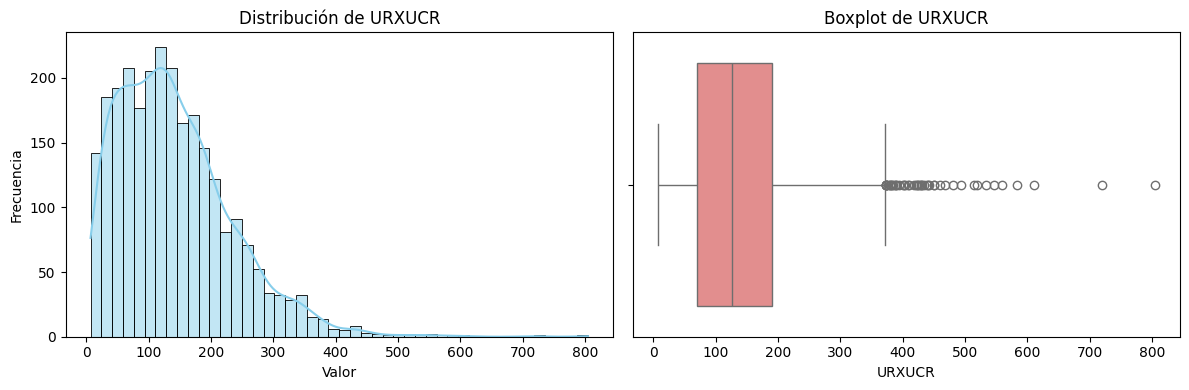

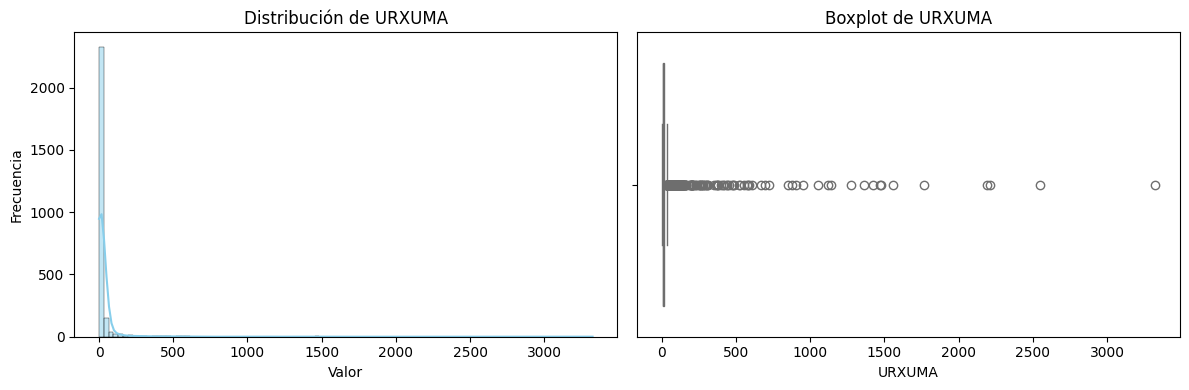

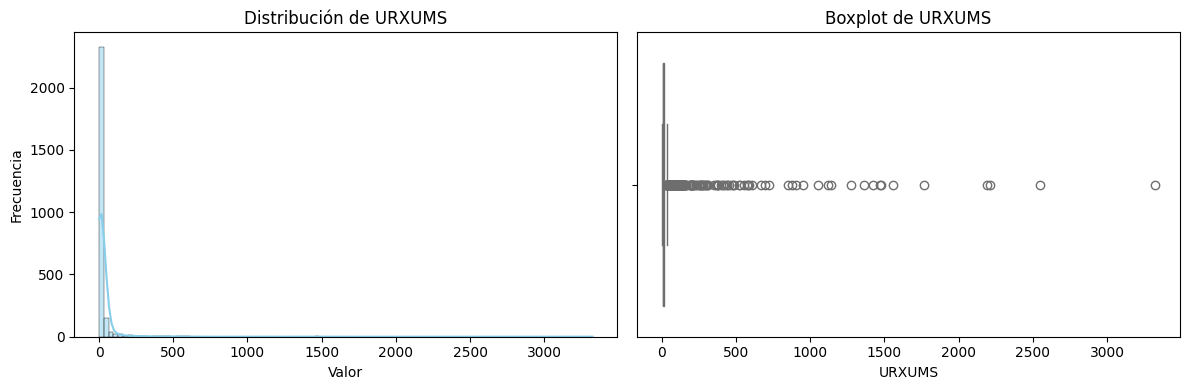

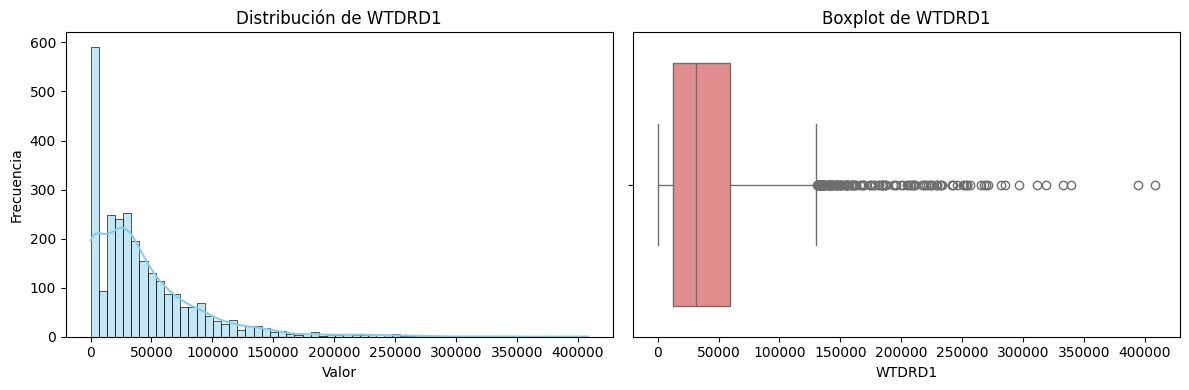

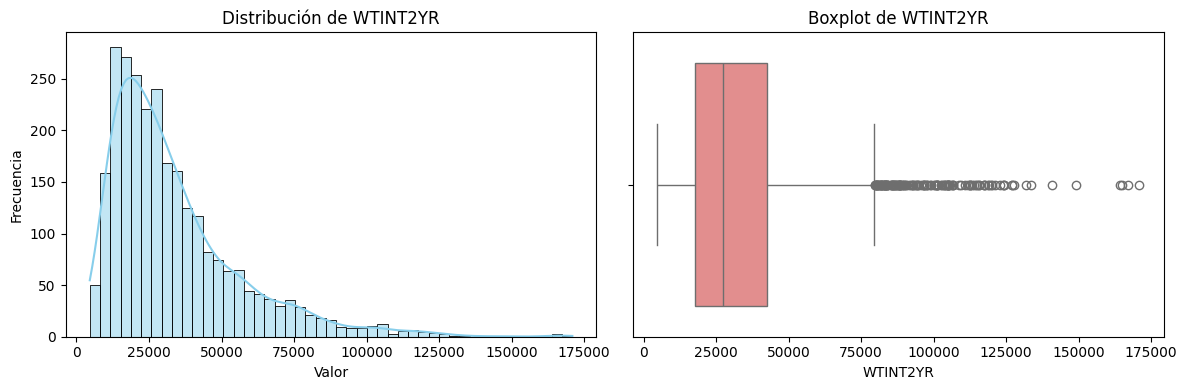

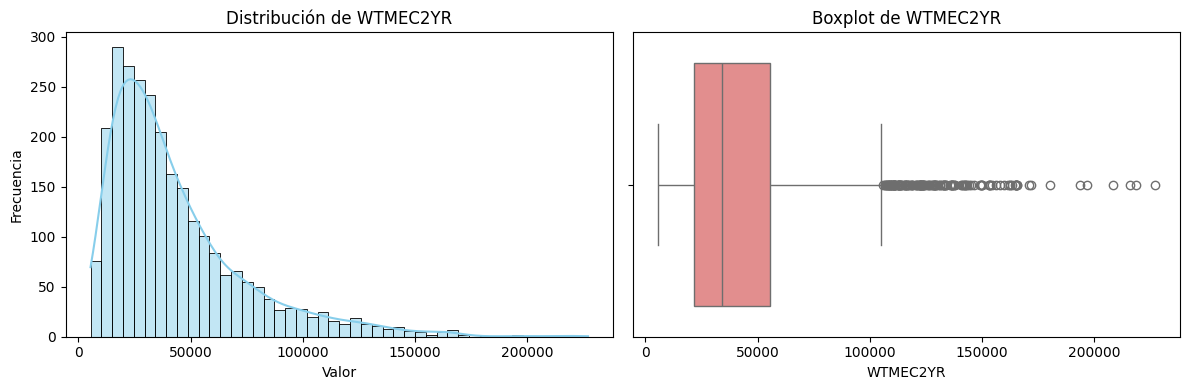

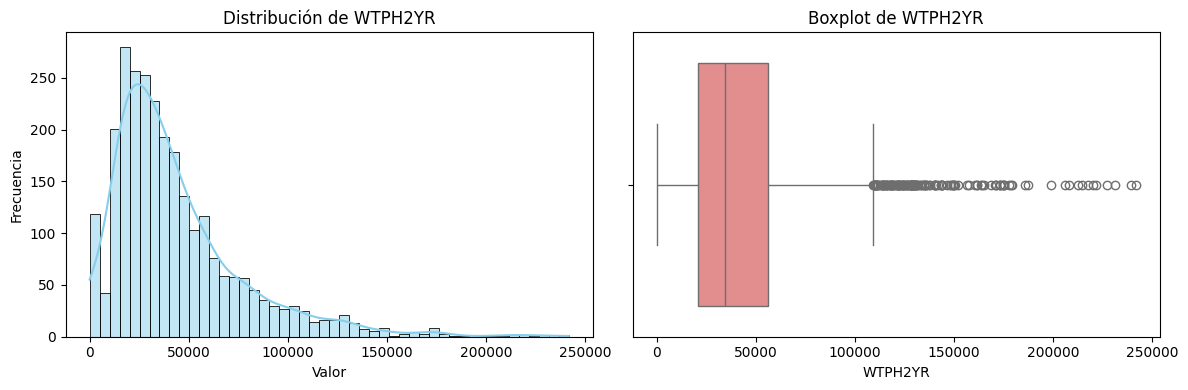

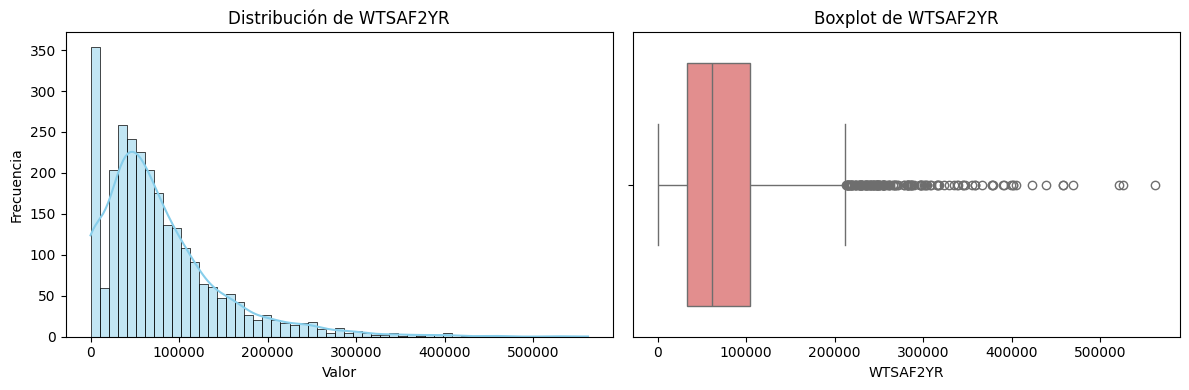

In [15]:
# Definimos el número de variables a visualizar por tanda para no saturar el cuaderno
vars_a_revisar = cols_numericas # Puedes cambiar el rango o usar cols_numericas completa

for col in vars_a_revisar:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histograma con KDE 
    sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribución de {col}')
    axes[0].set_xlabel('Valor')
    axes[0].set_ylabel('Frecuencia')
    
    # Boxplot 
    sns.boxplot(x=df[col], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot de {col}')
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

In [18]:
def count_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((data < lower_bound) | (data > upper_bound)).sum()

# Creamos un resumen
outlier_summary = []
for col in cols_numericas:
    n_outliers = count_outliers(df[col].dropna())
    pct_outliers = (n_outliers / len(df)) * 100
    outlier_summary.append({
        'Variable': col,
        'Num_Outliers': n_outliers,
        'Porcentaje': round(pct_outliers, 2)
    })

df_outliers = pd.DataFrame(outlier_summary).sort_values(by='Num_Outliers', ascending=False)

print("--- Outliers detectados ---")
print(df_outliers.to_string(index=False))

--- Outliers detectados ---
Variable  Num_Outliers  Porcentaje
LUANMVGP           645       24.00
BAXMSTAT           585       21.77
LBDTHGLC           462       17.19
DSD010AN           365       13.58
DSDANCNT           365       13.58
LUANMTGP           324       12.06
  URDACT           319       11.87
  URXUMA           304       11.31
  URXUMS           304       11.31
LUAXSTAT           300       11.16
  LBXBCD           261        9.71
LBDBCDSI           261        9.71
 LBDEONO           232        8.63
  LBXTHG           219        8.15
LBDTHGSI           219        8.15
LBXHSCRP           202        7.52
 LUXSMED           199        7.41
  BAQ150           197        7.33
URDUMALC           188        7.00
BMDSTATS           175        6.51
LBDBPBSI           170        6.33
 LUXSIQR           170        6.33
  LBXBPB           164        6.10
WTMEC2YR           150        5.58
  LBXRDW           148        5.51
 WTPH2YR           147        5.47
  WTDRD1           144     

## Correlaciones

--- Estadísticos Principales ---


,SDDSRVYR,RIDAGEYR,RIDEXMON,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR,WTDRD1,DSDCOUNT,...,LBDBCDSI,LBXTHG,LBDTHGSI,LBDTHGLC,LBXBSE,LBDBSESI,LBDBSELC,LBXBMN,LBDBMNSI,LBDBMNLC
count,2687.0,2687.000000,2687.000000,2687.000000,2687.000000,2687.000000,2687.000000,2.340000e+03,2.687000e+03,2.097000e+03,...,2559.000000,2559.000000,2559.000000,2.559000e+03,2559.000000,2559.000000,2.559000e+03,2559.000000,2559.000000,2.559000e+03
mean,12.0,48.335690,1.533309,33744.555021,43527.236978,179.695571,1.495720,2.964449e+00,4.348838e+04,1.904149e+00,...,3.741794,1.259043,6.283251,1.805393e-01,181.654592,2.306952,5.397605e-79,9.615397,175.019500,5.397605e-79
std,0.0,14.547777,0.498982,22776.816386,31132.137933,4.244351,0.500075,1.695561e+00,4.723495e+04,4.428381e+00,...,4.897708,2.095819,10.457813,3.847112e-01,28.278765,0.359172,0.000000e+00,3.529724,64.248113,0.000000e+00
min,12.0,20.000000,1.000000,4584.463196,5424.587296,173.000000,1.000000,5.397605e-79,5.397605e-79,5.397605e-79,...,0.409000,0.120000,0.600000,5.397605e-79,116.700000,1.480000,5.397605e-79,2.980000,54.240000,5.397605e-79
25%,12.0,35.000000,1.000000,17778.792108,21583.469361,176.000000,1.000000,1.400000e+00,1.282552e+04,5.397605e-79,...,1.406000,0.230000,1.150000,5.397605e-79,165.100000,2.100000,5.397605e-79,7.270000,132.330000,5.397605e-79
50%,12.0,50.000000,2.000000,27280.243838,34328.504575,180.000000,1.000000,2.920000e+00,3.137782e+04,1.000000e+00,...,2.215000,0.580000,2.890000,5.397605e-79,178.700000,2.270000,5.397605e-79,8.960000,163.090000,5.397605e-79
75%,12.0,62.000000,2.000000,42464.315819,55319.700248,183.000000,2.000000,5.000000e+00,5.979139e+04,3.000000e+00,...,3.915000,1.425000,7.115000,5.397605e-79,193.900000,2.460000,5.397605e-79,11.170000,203.320000,5.397605e-79
max,12.0,69.000000,2.000000,170968.343177,227108.296958,187.000000,2.000000,5.000000e+00,4.085058e+05,9.900000e+01,...,68.365000,29.540000,147.400000,1.000000e+00,752.400000,9.560000,5.397605e-79,42.950000,781.780000,5.397605e-79


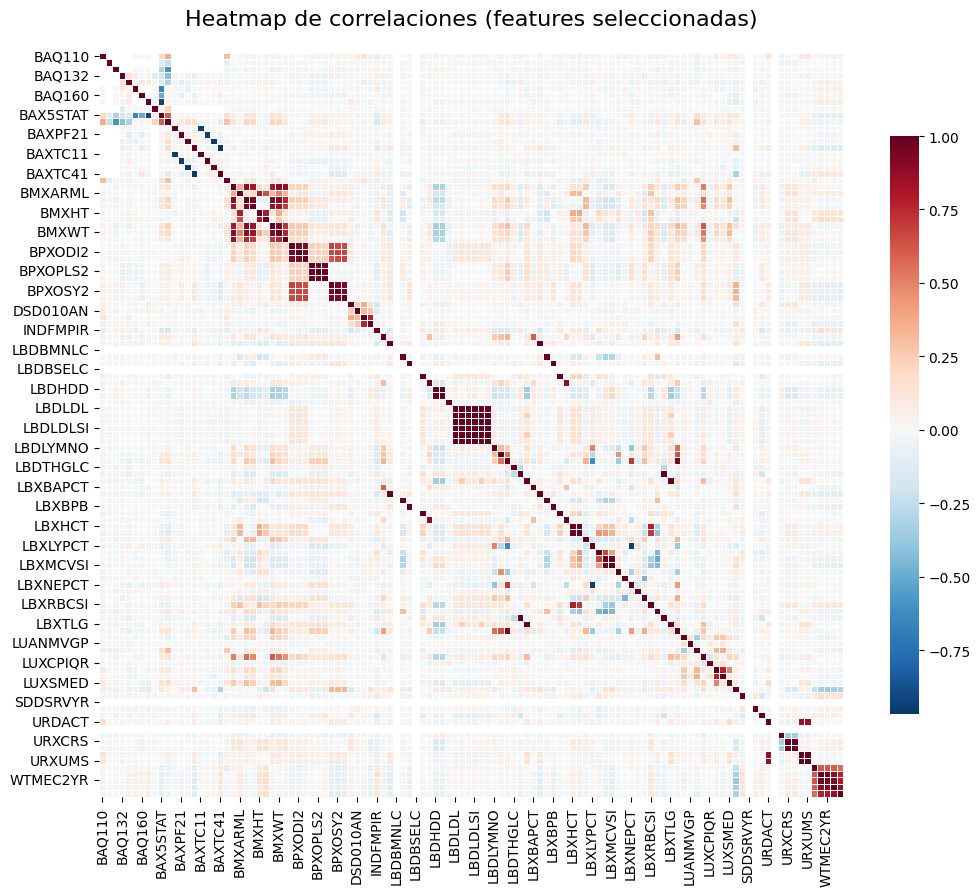

In [22]:
# 3. Análisis Estadístico Descriptivo
print("--- Estadísticos Principales ---")
display(df.describe())

# 4. Visualización de correlación 
# Calculamos la matriz
corr_matrix = df[cols_numericas].corr()

# Configuramos el tamaño de la figura
plt.figure(figsize=(12, 10))

# Dibujamos el heatmap 
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='RdBu_r', 
            center=0,
            linewidths=.5, 
            linecolor='white',
            square=True,
            cbar_kws={"shrink": .75})

# Ajustes de etiquetas y título
plt.title("Heatmap de correlaciones (features seleccionadas)", fontsize=16, pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()